In [1]:
# ============================================================================
# SECTION 1: MATHEMATICAL & STATISTICAL FOUNDATIONS
# ============================================================================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

from torch.func import grad, vmap
from torch.autograd.functional import hessian

import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# For better display in Jupyter
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
#plt.rcParams['figure.dpi'] = 100
#plt.rcParams['savefig.dpi'] = 150

# Check PyTorch version and device
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch {torch.__version__}")
print(f"Device:  {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
print("All imports successful!")

PyTorch 2.10.0+cpu
Device:  cpu
CUDA available: False
All imports successful!


In [2]:
# ---------- VECTORS AND MATRICES ----------

# Create a vector (a point in n-dimensional space)
x = torch.tensor([1.0, 2.0, 3.0, 4.0])
print(f"\nVector x ∈ ℝ⁴: {x}")
print(f"Shape: {x.shape}")
print(f"Data type: {x.dtype}")

# Create a matrix (linear transformation)
W = torch.tensor([[1.0, 2.0, 3.0, 4.0],
                  [5.0, 6.0, 7.0, 8.0],
                  [9.0, 10.0, 11.0, 12.0]])

print(f"\nMatrix W ∈ ℝ³ˣ⁴:\n{W}")
print(f"\nShape: {W.shape}")

# Linear layer: y = Wx + b
b = torch.tensor([0.1, 0.2, 0.3])
y = W @ x + b  

print(f"\nLinear layer output y = Wx + b: {y}")
print(f"Shape: {y.shape}")


Vector x ∈ ℝ⁴: tensor([1., 2., 3., 4.])
Shape: torch.Size([4])
Data type: torch.float32

Matrix W ∈ ℝ³ˣ⁴:
tensor([[ 1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12.]])

Shape: torch.Size([3, 4])

Linear layer output y = Wx + b: tensor([ 30.1000,  70.2000, 110.3000])
Shape: torch.Size([3])


In [3]:
# ---------- VECTORS AND MATRICES ----------

x = torch.tensor([1.0, 2.0, 3.0, 4.0])                       
W = torch.arange(1, 13, dtype=torch.float32).reshape(3, 4)   
b = torch.tensor([0.1, 0.2, 0.3])                            

y = W @ x + b                                                
print(f"x: {x.shape}, W: {W.shape}, y = Wx + b: {y.shape}")
print(f"y = {y}")

x: torch.Size([4]), W: torch.Size([3, 4]), y = Wx + b: torch.Size([3])
y = tensor([ 30.1000,  70.2000, 110.3000])


In [4]:
# ---------- TENSORS ----------
print("\n--- TENSORS ---")

# 4D tensor: (N, C, H, W) - batch of images
image_batch = torch.randn(32, 3, 224, 224)  
print(f"\n4D Tensor shape (N, C, H, W): {image_batch.shape}")
print(f"Total elements: {image_batch.numel():,}")                               

# Common tensor operations
tensor_a = torch.randn(3, 4)
tensor_b = torch.randn(3, 4)

print(f"\nTensor A shape: {tensor_a.shape}")
print(f"\nTensor A: \n{tensor_a}")
print(f"\nTensor B shape: {tensor_b.shape}")
print(f"Tensor B: \n{tensor_b}")

# Element-wise operations
elementwise_sum = tensor_a + tensor_b
print(f"\nElement-wise sum shape: {elementwise_sum.shape}")
print(f"Element-wise sum : {elementwise_sum}")

# Broadcasting: add a scalar to all elements
broadcasted = tensor_a + 5.0
print(f"\nBroadcasting (add scalar 5) shape: {broadcasted.shape}")
print(f"Broadcasting (add scalar 5) : \n{broadcasted}")

# Reshaping
reshaped = tensor_a.reshape(4, 3)
print(f"\nReshaped from (3,4) to (4,3): {reshaped.shape}")
print(f"\nTensor A reshaped: \n{reshaped}")

# Reduction operations
mean_value = tensor_a.mean()
sum_value1 = tensor_a.sum(dim=0)  
sum_value2 = tensor_a.sum(dim=1)  

print(f"\nMean of tensor_a: {mean_value.item():.4f}")
print(f"Sum along dim 0 (rows): {sum_value1}")
print(f"Sum along dim 1 (columns): {sum_value2}")


--- TENSORS ---

4D Tensor shape (N, C, H, W): torch.Size([32, 3, 224, 224])
Total elements: 4,816,896

Tensor A shape: torch.Size([3, 4])

Tensor A: 
tensor([[ 1.4530,  0.4852, -1.3984, -3.4272],
        [ 0.8047,  1.4330, -0.9260,  1.3191],
        [ 1.1393, -0.2714, -1.0849,  1.4883]])

Tensor B shape: torch.Size([3, 4])
Tensor B: 
tensor([[ 0.0651, -0.2015, -0.8832,  0.6644],
        [ 1.3925, -0.0860, -0.2487,  0.2400],
        [-1.2479, -0.0610,  0.2536, -1.3853]])

Element-wise sum shape: torch.Size([3, 4])
Element-wise sum : tensor([[ 1.5182,  0.2838, -2.2816, -2.7628],
        [ 2.1972,  1.3470, -1.1746,  1.5591],
        [-0.1086, -0.3324, -0.8312,  0.1030]])

Broadcasting (add scalar 5) shape: torch.Size([3, 4])
Broadcasting (add scalar 5) : 
tensor([[6.4530, 5.4852, 3.6016, 1.5728],
        [5.8047, 6.4330, 4.0740, 6.3191],
        [6.1393, 4.7286, 3.9151, 6.4883]])

Reshaped from (3,4) to (4,3): torch.Size([4, 3])

Tensor A reshaped: 
tensor([[ 1.4530,  0.4852, -1.3984],


In [5]:
# ---------- TENSORS ----------
# A 4D tensor of shape (N, C, H, W) = a mini-batch of images
batch = torch.randn(32, 3, 224, 224)
print(f"\nImage batch: {batch.shape}  ({batch.numel():,} elements)\n")

# Common tensor ops — all vectorized
a = torch.randn(3, 4)
print(f"a + 5.0        : {a.shape}")             
print(f"a.mean(dim=0)  : {a.mean(dim=0).shape}")   
print(f"a.mean(dim=1)  : {a.mean(dim=1).shape}")   
print(f"a.reshape(4,3) : {a.reshape(4, 3).shape}") 


Image batch: torch.Size([32, 3, 224, 224])  (4,816,896 elements)

a + 5.0        : torch.Size([3, 4])
a.mean(dim=0)  : torch.Size([4])
a.mean(dim=1)  : torch.Size([3])
a.reshape(4,3) : torch.Size([4, 3])


In [6]:
# ---------- KEY OPERATIONS ----------
print("\n--- KEY LINEAR ALGEBRA OPERATIONS ---")

# Dot product
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])
dot_product = torch.dot(x, y)
print(f"Dot product x·y = {dot_product.item():.0f} (measures alignment/similarity)")


--- KEY LINEAR ALGEBRA OPERATIONS ---
Dot product x·y = 32 (measures alignment/similarity)


In [7]:
# Matrix multiplication
A = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
B = torch.tensor([[5.0, 6.0], [7.0, 8.0]])
AB = torch.mm(A, B)  # matrix multiplication
print(f"\nMatrix A:\n{A}")
print(f"Matrix B:\n{B}")
print(f"\nA @ B (composition of transformations):\n{AB}")

# For batched matrix multiplication (common in DL)
batch_size = 4
A_batch = torch.randn(batch_size, 2, 3)
B_batch = torch.randn(batch_size, 3, 4)
AB_batch = torch.bmm(A_batch, B_batch)        

print(f"\nBatched matrix multiplication:")
print(f"A_batch shape: {A_batch.shape}")
print(f"A_batch: \n{A_batch}")
print(f"\nB_batch shape: {B_batch.shape}")
print(f"B_batch: \n{B_batch}")
print(f"\nAB_batch shape: {AB_batch.shape}")
print(f"AB_batch: \n{AB_batch}")

# Transpose
AT = A.T  # or A.transpose(0, 1)
print(f"\nAᵀ (transpose):\n{AT}")


Matrix A:
tensor([[1., 2.],
        [3., 4.]])
Matrix B:
tensor([[5., 6.],
        [7., 8.]])

A @ B (composition of transformations):
tensor([[19., 22.],
        [43., 50.]])

Batched matrix multiplication:
A_batch shape: torch.Size([4, 2, 3])
A_batch: 
tensor([[[ 0.7596, -0.7247, -0.0502],
         [-1.3814, -0.0060,  0.2426]],

        [[-1.2311,  0.9149,  0.5259],
         [-0.5878, -1.1146, -0.7106]],

        [[-0.1079, -1.8603,  0.2721],
         [-0.5785, -1.3928, -0.5486]],

        [[-0.0833,  1.0063,  1.3027],
         [ 0.0574, -0.8435,  0.0238]]])

B_batch shape: torch.Size([4, 3, 4])
B_batch: 
tensor([[[ 2.5363, -0.1670, -1.6562,  1.7089],
         [ 1.0955, -1.1181, -0.4477, -0.8577],
         [ 0.3050, -0.5317,  0.0545, -1.8855]],

        [[ 0.0527,  1.0281,  1.5176, -1.5215],
         [ 0.1764,  1.6189,  1.2226, -0.7373],
         [-0.2072,  1.2845, -1.2932, -0.7574]],

        [[ 0.1230,  0.4790,  0.3189,  2.4924],
         [-0.1376, -1.0061, -0.8082,  0.2938],
    

In [8]:
# ---------- DOT PRODUCT ----------
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])
print(f"x·y = {torch.dot(x, y).item()}")

# ---------- MATRIX MULTIPLICATION ----------
A = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
B = torch.tensor([[5.0, 6.0], [7.0, 8.0]])
print(f"\nA @ B =\n{A @ B}")

# ---------- BATCHED MATMUL (no Python loops) ----------
A_b = torch.randn(32, 2, 3)
B_b = torch.randn(32, 3, 4)
print(f"\nbmm:    {A_b.shape} @ {B_b.shape} → {(A_b @ B_b).shape}")
print(f"einsum: {torch.einsum('bij,bjk->bik', A_b, B_b).shape}")          

B_b_T =torch.einsum('bkj', B_b)            # (32, 4, 3)
print(f"\nB_b_T : {B_b_T.shape}")

# einsum automatically handles the transpose of B on the fly!
print(f"einsum: {torch.einsum('bij,bkj->bik', A_b, B_b_T).shape}")

# ---------- TRANSPOSE ----------
print(f"\nAᵀ =\n{A.T}")

x·y = 32.0

A @ B =
tensor([[19., 22.],
        [43., 50.]])

bmm:    torch.Size([32, 2, 3]) @ torch.Size([32, 3, 4]) → torch.Size([32, 2, 4])
einsum: torch.Size([32, 2, 4])

B_b_T : torch.Size([32, 4, 3])
einsum: torch.Size([32, 2, 4])

Aᵀ =
tensor([[1., 3.],
        [2., 4.]])



--- EIGEN DECOMPOSITION PyTorch---
Matrix A:
tensor([[2., 1.],
        [1., 2.]])
Eigenvalues are returned in ascending order: tensor([1., 3.])
Eigenvectors (columns):
tensor([[-0.7071,  0.7071],
        [ 0.7071,  0.7071]])
These reveal the 'stretching directions' of the linear transformation


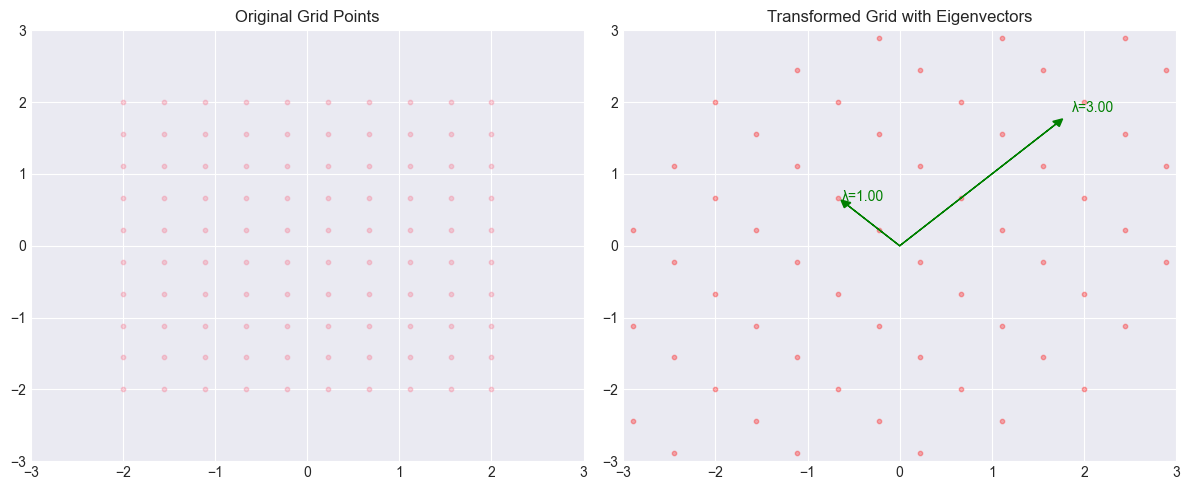

Eigendecomposition visualization complete!


In [9]:
# ---------- EIGEN DECOMPOSITION ----------

print("\n--- EIGEN DECOMPOSITION PyTorch---")

# PyTorch doesn't have native eigen decomposition for CUDA tensors
# We'll use CPU for this demonstration
A = torch.tensor([[2.0, 1.0], [1.0, 2.0]])                      

# Compute eigenvalues and eigenvectors using torch.linalg.eigh (for symmetric matrices)
eigenvalues, eigenvectors = torch.linalg.eigh(A)

print(f"Matrix A:\n{A}")
print(f"Eigenvalues are returned in ascending order: {eigenvalues}")
print(f"Eigenvectors (columns):\n{eigenvectors}")
print("These reveal the 'stretching directions' of the linear transformation")

# Convert to numpy for visualization
A_np = A.numpy()
eigenvalues_np = eigenvalues.numpy()
eigenvectors_np = eigenvectors.numpy()

# Visualize eigenvectors
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original grid
x_vals = np.linspace(-2, 2, 10)
y_vals = np.linspace(-2, 2, 10)
X, Y = np.meshgrid(x_vals, y_vals)           
points = np.vstack([X.ravel(), Y.ravel()])   
                                             

# Transform grid
transformed_points = A_np @ points           
X_trans = transformed_points[0, :].reshape(X.shape)     # 100 -> 10 x 10
Y_trans = transformed_points[1, :].reshape(Y.shape)     # 100 -> 10 x 10


# Plot original grid
axes[0].scatter(points[0, :], points[1, :], alpha=0.3, s=10)       
axes[0].set_title('Original Grid Points')
axes[0].set_xlim(-3, 3)
axes[0].set_ylim(-3, 3)
axes[0].grid(True)

# Plot transformed grid with eigenvectors
axes[1].scatter(X_trans, Y_trans, alpha=0.3, s=10, c='red')
# Plot eigenvectors
for i in range(2):
    vec = eigenvectors_np[:, i]
    scale = eigenvalues_np[i] * 0.8
    axes[1].arrow(0, 0, vec[0] * scale, vec[1] * scale, 
                  head_width=0.1, head_length=0.1, fc='green', ec='green')
    axes[1].text(vec[0] * scale * 1.1, vec[1] * scale * 1.1, 
                 f'λ={eigenvalues_np[i]:.2f}', fontsize=10, color='green')

axes[1].set_title(f'Transformed Grid with Eigenvectors')
axes[1].set_xlim(-3, 3)
axes[1].set_ylim(-3, 3)
axes[1].grid(True)

plt.tight_layout()
plt.show()
print("Eigendecomposition visualization complete!")

In [10]:
# ---------- EIGEN DECOMPOSITION  - NUMPY VERSION ----------

import numpy as np
from scipy.linalg import eig, svd

print("\n--- EIGEN DECOMPOSITION ---")
A = np.array([[2, 1], [1, 2]])

eigenvalues, eigenvectors = eig(A)         

print(f"Matrix A:\n{A}")
print(f"\nEigenvalues sorting order not guranteed : {eigenvalues}")
print(f"\nEigenvectors (columns): In NumPy, the eigenvectors are stored as columns, not rows. \n{eigenvectors}")
print("\nThese reveal the 'stretching directions' of the linear transformation")


--- EIGEN DECOMPOSITION ---
Matrix A:
[[2 1]
 [1 2]]

Eigenvalues sorting order not guranteed : [3.+0.j 1.+0.j]

Eigenvectors (columns): In NumPy, the eigenvectors are stored as columns, not rows. 
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

These reveal the 'stretching directions' of the linear transformation


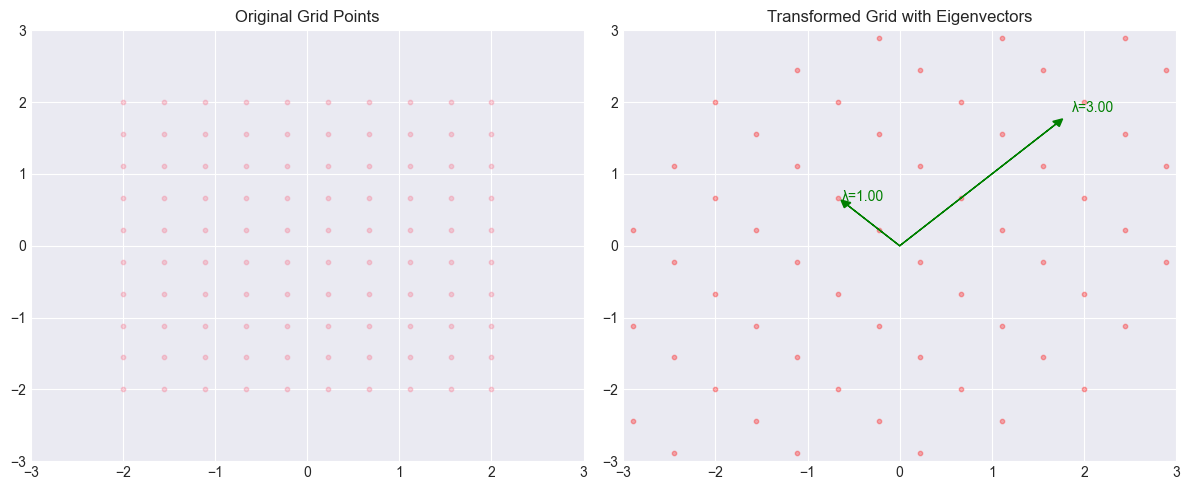

Eigendecomposition visualization complete!


In [11]:
# Visualize eigenvectors
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original grid
x_vals = np.linspace(-2, 2, 10)
y_vals = np.linspace(-2, 2, 10)
X, Y = np.meshgrid(x_vals, y_vals)
points = np.vstack([X.ravel(), Y.ravel()])

# Transform grid
transformed_points = A @ points
X_trans = transformed_points[0, :].reshape(X.shape)
Y_trans = transformed_points[1, :].reshape(Y.shape)

# Plot original grid
axes[0].scatter(points[0, :], points[1, :], alpha=0.3, s=10)
axes[0].set_title('Original Grid Points')
axes[0].set_xlim(-3, 3)
axes[0].set_ylim(-3, 3)
axes[0].grid(True)

# Plot transformed grid with eigenvectors
axes[1].scatter(X_trans, Y_trans, alpha=0.3, s=10, c='red')
# Plot eigenvectors
for i in range(2):
    vec = eigenvectors[:, i]
    scale = eigenvalues[i].real * 0.8
    axes[1].arrow(0, 0, vec[0] * scale, vec[1] * scale, 
                  head_width=0.1, head_length=0.1, fc='green', ec='green')
    axes[1].text(vec[0] * scale * 1.1, vec[1] * scale * 1.1, 
                 f'λ={eigenvalues[i].real:.2f}', fontsize=10, color='green')

axes[1].set_title(f'Transformed Grid with Eigenvectors')
axes[1].set_xlim(-3, 3)
axes[1].set_ylim(-3, 3)
axes[1].grid(True)

plt.tight_layout()
plt.show()
print("Eigendecomposition visualization complete!")

A =
tensor([[2., 1.],
        [1., 2.]])
eigenvalues:  [1.0, 3.0]
eigenvectors:
tensor([[-0.7071,  0.7071],
        [ 0.7071,  0.7071]])


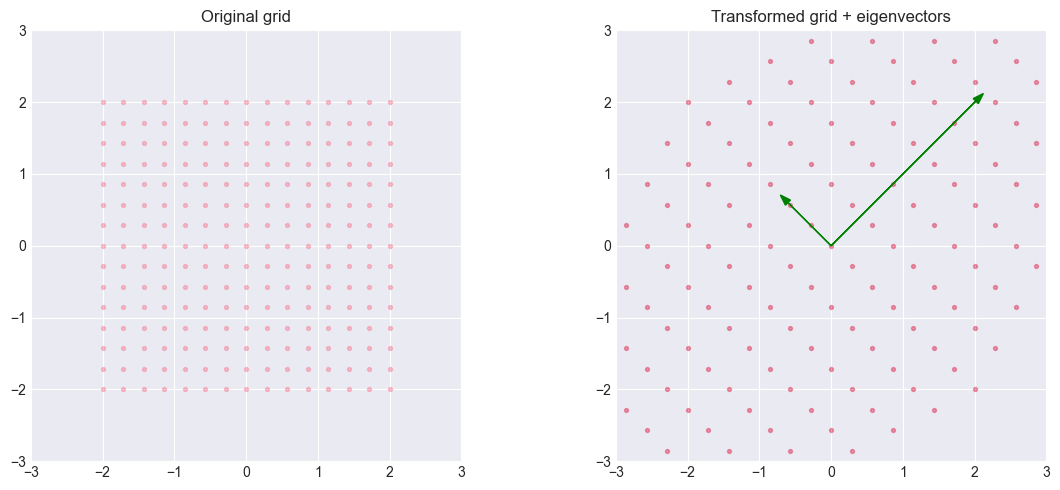

In [12]:
# ---------- EIGENDECOMPOSITION ----------

A = torch.tensor([[2.0, 1.0], [1.0, 2.0]])
eigenvalues, eigenvectors = torch.linalg.eigh(A)

print(f"A =\n{A}")
print(f"eigenvalues:  {eigenvalues.tolist()}")
print(f"eigenvectors:\n{eigenvectors}")

x = torch.linspace(-2, 2, 15)
X, Y = torch.meshgrid(x, x, indexing='ij')
pts = torch.stack([X.flatten(), Y.flatten()], dim=1)                      
tpts = pts @ A.T                                                          
Xt, Yt = tpts[:, 0].reshape(X.shape), tpts[:, 1].reshape(Y.shape)         

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.4)
axes[0].set(title='Original grid', xlim=(-3, 3), ylim=(-3, 3), aspect='equal')

axes[1].scatter(Xt, Yt, s=8, alpha=0.4, c='crimson')
for i in range(2):
    v = eigenvectors[:, i]
    s = eigenvalues[i].item()
    axes[1].arrow(0, 0, v[0]*s, v[1]*s, head_width=0.1,
                  color='green', length_includes_head=True)
axes[1].set(title='Transformed grid + eigenvectors', xlim=(-3, 3), ylim=(-3, 3), aspect='equal')
plt.tight_layout(); plt.show()

In [13]:
# ---------- SINGULAR VALUE DECOMPOSITION (SVD) ----------

print("\n--- SINGULAR VALUE DECOMPOSITION (SVD) PyTorch ---")

A = torch.tensor([[1.0, 2.0, 3.0], 
                  [4.0, 5.0, 6.0], 
                  [7.0, 8.0, 9.0]])

U, S, Vt = torch.linalg.svd(A, full_matrices=False)       

print(f"Matrix A:\n{A}")
print(f"U (left singular vectors):\n{U}")                        
print(f"Σ (singular values): {S}")                               
print(f"Vᵀ (transpose of the right singular vectors):\n{Vt}")    
                                                                 
Sigma = torch.zeros_like(A, dtype=torch.float)
Sigma[:len(S), :len(S)] = torch.diag(S)
A_reconstructed = U @ Sigma @ Vt
print(f"\nReconstructed A:\n{A_reconstructed}")
print(f"Error: {torch.max(torch.abs(A - A_reconstructed)).item():.2e}")

def svd_compression_torch(A, rank):
    """Compress matrix using SVD with given rank (PyTorch version)"""
    U, S, Vt = torch.linalg.svd(A, full_matrices=False)
    Sigma = torch.zeros((len(S), len(S)), dtype=A.dtype)
    Sigma[:rank, :rank] = torch.diag(S[:rank])
    return U[:, :rank] @ Sigma[:rank, :rank] @ Vt[:rank, :]


print("\n--- SVD for Compression ---")
A_rank2 = svd_compression_torch(A, 2)            
print(f"Original A:\n{A}")
print(f"Rank-2 approximation:\n{A_rank2}")
relative_error = torch.norm(A - A_rank2) / torch.norm(A)              
print(f"Relative error: {relative_error.item():.4f}")

print("\nSVD used in compression, denoising, and LoRA in deep learning")


--- SINGULAR VALUE DECOMPOSITION (SVD) PyTorch ---
Matrix A:
tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])
U (left singular vectors):
tensor([[-0.2148,  0.8872,  0.4082],
        [-0.5206,  0.2496, -0.8165],
        [-0.8263, -0.3879,  0.4082]])
Σ (singular values): tensor([1.6848e+01, 1.0684e+00, 1.0313e-07])
Vᵀ (transpose of the right singular vectors):
tensor([[-0.4797, -0.5724, -0.6651],
        [-0.7767, -0.0757,  0.6253],
        [-0.4082,  0.8165, -0.4082]])

Reconstructed A:
tensor([[1.0000, 2.0000, 3.0000],
        [4.0000, 5.0000, 6.0000],
        [7.0000, 8.0000, 9.0000]])
Error: 1.91e-06

--- SVD for Compression ---
Original A:
tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])
Rank-2 approximation:
tensor([[1.0000, 2.0000, 3.0000],
        [4.0000, 5.0000, 6.0000],
        [7.0000, 8.0000, 9.0000]])
Relative error: 0.0000

SVD used in compression, denoising, and LoRA in deep learning


In [14]:
# ---------- SINGULAR VALUE DECOMPOSITION (SVD) ----------

print("\n--- SINGULAR VALUE DECOMPOSITION (SVD)  Numpy ---")
A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
U, S, Vt = svd(A)

print(f"\nMatrix A:\n{A}")
print(f"\nU (left singular vectors):\n{U}")
print(f"\nΣ (singular values): {S}")
print(f"\nVᵀ (right singular vectors):\n{Vt}")


--- SINGULAR VALUE DECOMPOSITION (SVD)  Numpy ---

Matrix A:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

U (left singular vectors):
[[-0.21483724  0.88723069  0.40824829]
 [-0.52058739  0.24964395 -0.81649658]
 [-0.82633754 -0.38794278  0.40824829]]

Σ (singular values): [1.68481034e+01 1.06836951e+00 3.33475287e-16]

Vᵀ (right singular vectors):
[[-0.47967118 -0.57236779 -0.66506441]
 [-0.77669099 -0.07568647  0.62531805]
 [-0.40824829  0.81649658 -0.40824829]]


In [15]:
# Verify: A = U @ Σ @ Vᵀ
Sigma = np.zeros_like(A, dtype=float)
Sigma[:len(S), :len(S)] = np.diag(S)
A_reconstructed = U @ Sigma @ Vt
print(f"\nReconstructed A: {A_reconstructed}")
print(f"\nError: {np.max(np.abs(A - A_reconstructed)):.2e}")


Reconstructed A: [[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]

Error: 6.66e-15


In [16]:
# Demonstrate SVD for compression
def svd_compression(A, rank):
    """Compress matrix using SVD with given rank"""
    U, S, Vt = svd(A, full_matrices=False)
    Sigma = np.zeros((len(S), len(S)))
    Sigma[:rank, :rank] = np.diag(S[:rank])
    return U[:, :rank] @ Sigma[:rank, :rank] @ Vt[:rank, :]

print("\n--- SVD for Compression ---")
A_rank2 = svd_compression(A, 2)
print(f"\nOriginal A:\n{A}")
print(f"\nRank-2 approximation:\n{A_rank2}")
print(f"\nRelative error: {np.linalg.norm(A - A_rank2) / np.linalg.norm(A):.4f}")

print("\nSVD used in compression, denoising, and LoRA in deep learning")


--- SVD for Compression ---

Original A:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Rank-2 approximation:
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]

Relative error: 0.0000

SVD used in compression, denoising, and LoRA in deep learning


In [17]:
# ---------- SVD ----------
A = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0],
                  [7.0, 8.0, 9.0]])

U, S, Vt = torch.linalg.svd(A, full_matrices=False)

A_rec = (U * S) @ Vt
print(f"Reconstruction error: {(A - A_rec).abs().max().item():.2e}")

# Low-rank compression
def low_rank(A, k):
    U, S, Vt = torch.linalg.svd(A, full_matrices=False)
    return (U[:, :k] * S[:k]) @ Vt[:k]

A2 = low_rank(A, 2)
rel_err = (torch.norm(A - A2) / torch.norm(A)).item()
print(f"Rank-2 relative error: {rel_err:.4f}")
print("\nSVD is the mathematical foundation of LoRA and model compression.")

Reconstruction error: 1.91e-06
Rank-2 relative error: 0.0000

SVD is the mathematical foundation of LoRA and model compression.


In [18]:
# ---------- DERIVATIVES WITH AUTOMATIC DIFFERENTIATION ----------
print("\n--- DERIVATIVES WITH AUTOMATIC DIFFERENTIATION ---")

# Define a function with requires_grad
def f_pytorch(x):
    return x**2 + 2*x + 1

# Create input tensor with gradient tracking
x = torch.linspace(-3, 3, 100, requires_grad=True)
y = f_pytorch(x)

x0 = torch.tensor(1.0, requires_grad=True)
y0 = f_pytorch(x0)
y0.backward()  # Compute gradient
print(f"At x = {x0.item():.1f}:")
print(f"   f(x) = {y0.item():.2f}")
print(f"   f'(x) = {x0.grad.item():.2f} (computed with PyTorch autograd)")
print(f"   Analytical: 2x + 2 = {2*x0.item() + 2:.2f}")


--- DERIVATIVES WITH AUTOMATIC DIFFERENTIATION ---
At x = 1.0:
   f(x) = 4.00
   f'(x) = 4.00 (computed with PyTorch autograd)
   Analytical: 2x + 2 = 4.00


In [19]:
# PEDAGOGICAL ONLY — loop-based, for understanding the math.

def f_scaler(x):
    return x**2 + 2*x + 1

x_vals = torch.linspace(-3, 3, 100)
y_vals = torch.zeros_like(x_vals)
dy_vals = torch.zeros_like(x_vals)

for i in range(len(x_vals)):
    x_i = x_vals[i].detach().clone().requires_grad_(True)
    y_i = f_scaler(x_i)
    y_i.backward()
    y_vals[i] = y_i.detach()
    dy_vals[i] = x_i.grad.detach()

print(f"Computed {len(x_vals)} gradients one at a time.")

Computed 100 gradients one at a time.


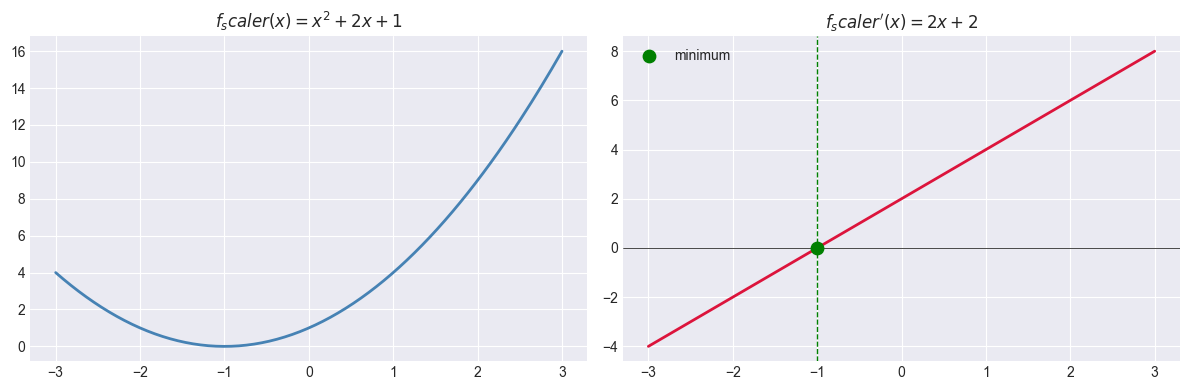

In [20]:
# PRODUCTION IDIOM

def f_scaler(x):
    return x**2 + 2*x + 1

df_scaler = grad(f_scaler)          
x  = torch.linspace(-3, 3, 200)
y  = vmap(f_scaler)(x)              
dy = vmap(df_scaler)(x)             

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x, y, lw=2, color='steelblue')
axes[0].set_title(r'$f_scaler(x) = x^2 + 2x + 1$')

axes[1].plot(x, dy, lw=2, color='crimson')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].axvline(-1, color='green', ls='--', lw=1)
axes[1].scatter([-1], [0], color='green', s=80, zorder=5, label='minimum')
axes[1].set_title(r"$f_scaler'(x) = 2x + 2$")
axes[1].legend()
plt.tight_layout(); plt.show()

Why it matters: The loop runs 100 forward+backward passes; vmap runs one batched call. On a GPU the gap is orders of magnitude. This is the single most important idiom in PyTorch code.

In [21]:
# ---------- GRADIENT DESCENT WITH PYTORCH ----------
print("\n--- GRADIENT DESCENT WITH PYTORCH ---")

def f_vector_pytorch(x):
    """f(x1, x2) = x1² + x2²"""
    return x[0]**2 + x[1]**2

x = torch.tensor([1.5, 1.5], requires_grad=True)

trajectory = [x.detach().clone().numpy()]    
learning_rate = 0.1

for i in range(30):
    loss = f_vector_pytorch(x)       
    
    loss.backward()                  
    # Update parameters
    with torch.no_grad():              
        x -= learning_rate * x.grad    
        x.grad.zero_()                 
    trajectory.append(x.detach().clone().numpy())

trajectory = np.array(trajectory)
print(f"\ntrajectory:\n{trajectory}\n")


--- GRADIENT DESCENT WITH PYTORCH ---

trajectory:
[[1.5        1.5       ]
 [1.2        1.2       ]
 [0.96000004 0.96000004]
 [0.768      0.768     ]
 [0.6144     0.6144    ]
 [0.49152002 0.49152002]
 [0.393216   0.393216  ]
 [0.3145728  0.3145728 ]
 [0.25165826 0.25165826]
 [0.20132661 0.20132661]
 [0.16106129 0.16106129]
 [0.12884903 0.12884903]
 [0.10307922 0.10307922]
 [0.08246338 0.08246338]
 [0.0659707  0.0659707 ]
 [0.05277656 0.05277656]
 [0.04222125 0.04222125]
 [0.033777   0.033777  ]
 [0.0270216  0.0270216 ]
 [0.02161728 0.02161728]
 [0.01729383 0.01729383]
 [0.01383506 0.01383506]
 [0.01106805 0.01106805]
 [0.00885444 0.00885444]
 [0.00708355 0.00708355]
 [0.00566684 0.00566684]
 [0.00453347 0.00453347]
 [0.00362678 0.00362678]
 [0.00290142 0.00290142]
 [0.00232114 0.00232114]
 [0.00185691 0.00185691]]



X shape : (20, 20)
X : 
[[-2.         -1.78947368 -1.57894737 -1.36842105 -1.15789474 -0.94736842
  -0.73684211 -0.52631579 -0.31578947 -0.10526316  0.10526316  0.31578947
   0.52631579  0.73684211  0.94736842  1.15789474  1.36842105  1.57894737
   1.78947368  2.        ]
 [-2.         -1.78947368 -1.57894737 -1.36842105 -1.15789474 -0.94736842
  -0.73684211 -0.52631579 -0.31578947 -0.10526316  0.10526316  0.31578947
   0.52631579  0.73684211  0.94736842  1.15789474  1.36842105  1.57894737
   1.78947368  2.        ]
 [-2.         -1.78947368 -1.57894737 -1.36842105 -1.15789474 -0.94736842
  -0.73684211 -0.52631579 -0.31578947 -0.10526316  0.10526316  0.31578947
   0.52631579  0.73684211  0.94736842  1.15789474  1.36842105  1.57894737
   1.78947368  2.        ]
 [-2.         -1.78947368 -1.57894737 -1.36842105 -1.15789474 -0.94736842
  -0.73684211 -0.52631579 -0.31578947 -0.10526316  0.10526316  0.31578947
   0.52631579  0.73684211  0.94736842  1.15789474  1.36842105  1.57894737
   1.78

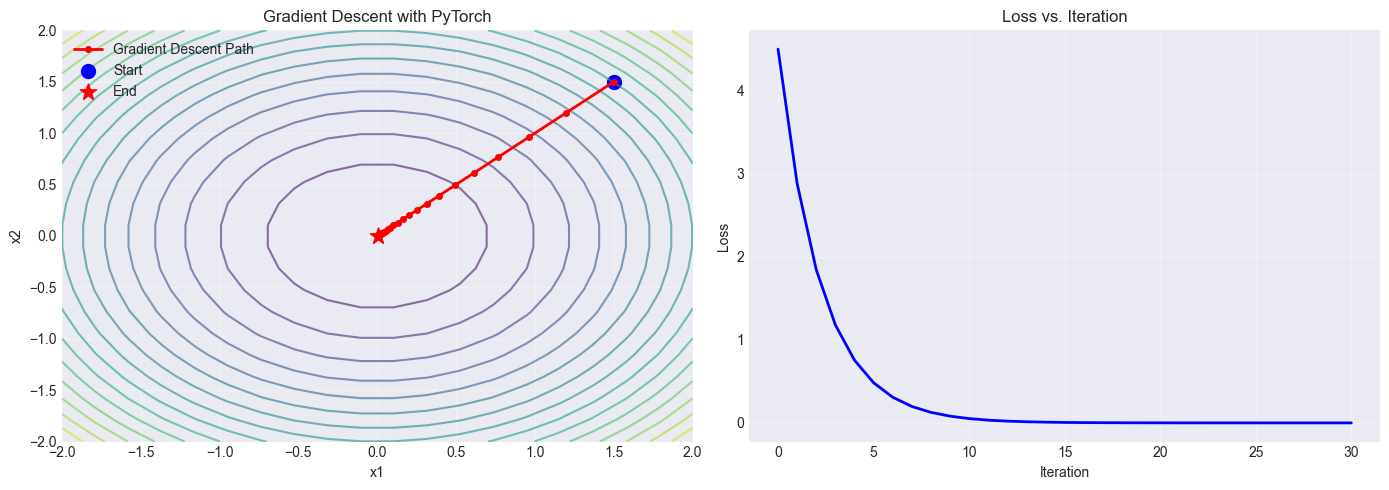

In [22]:
# Visualize gradient descent path
x_range = np.linspace(-2, 2, 20)
y_range = np.linspace(-2, 2, 20)

X, Y = np.meshgrid(x_range, y_range)              
Z = X**2 + Y**2

print(f"X shape : {X.shape}")
print(f"X : \n{X}")
print(f"\nY shape : {Y.shape}")
print(f"Y : \n{Y}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contour plot with trajectory
contour = axes[0].contour(X, Y, Z, levels=15, cmap='viridis', alpha=0.6)
axes[0].plot(trajectory[:, 0], trajectory[:, 1], 'r.-', linewidth=2, 
             markersize=8, label='Gradient Descent Path')
axes[0].scatter(trajectory[0, 0], trajectory[0, 1], color='blue', s=100, label='Start')
axes[0].scatter(trajectory[-1, 0], trajectory[-1, 1], color='red', s=150, marker='*', label='End')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].set_title(f'Gradient Descent with PyTorch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss over iterations
losses = [f_vector_pytorch(torch.tensor(p)) for p in trajectory]
axes[1].plot(range(len(losses)), losses, 'b-', linewidth=2)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss vs. Iteration')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Final point: [0.0018569102976471186, 0.0018569102976471186]


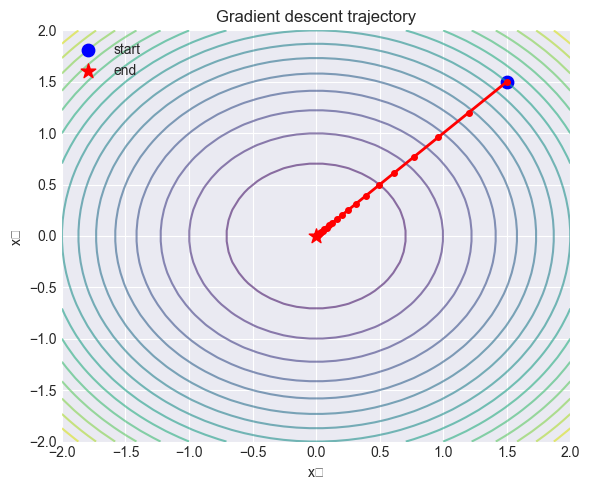

Gradient descent with PyTorch autograd complete!


In [23]:
#  gradient descent is inherently sequential — each step depends on the previous one. A Python loop is the correct and idiomatic choice.

def f(p):
    return (p**2).sum()

x = torch.tensor([1.5, 1.5], requires_grad=True)
lr = 0.1
trajectory = [x.detach().clone()]

for _ in range(30):
    loss = f(x)
    loss.backward()
    with torch.no_grad():
        x -= lr * x.grad
        x.grad.zero_()
    trajectory.append(x.detach().clone())

trajectory = torch.stack(trajectory)   # (31, 2)
print(f"Final point: {trajectory[-1].tolist()}")

# Visualize
g = torch.linspace(-2, 2, 40)
X, Y = torch.meshgrid(g, g, indexing='ij')     # X (40, 40), Y (40, 40)
Z = X**2 + Y**2

fig, ax = plt.subplots(figsize=(6, 5))
ax.contour(X, Y, Z, levels=15, cmap='viridis', alpha=0.6)
ax.plot(trajectory[:, 0], trajectory[:, 1], 'r.-', lw=2, ms=8)
ax.scatter(*trajectory[0],  c='blue', s=80, label='start')
ax.scatter(*trajectory[-1], c='red',  s=120, marker='*', label='end')
ax.set(title='Gradient descent trajectory', xlabel='x₁', ylabel='x₂')
ax.legend(); plt.tight_layout(); plt.show()
print("Gradient descent with PyTorch autograd complete!")

In [24]:
# ---------- GRADIENT VISUALIZATION ----------

print("\n--- GRADIENT VISUALIZATION WITH PYTORCH ---\n")

# Define function
def f_2d(x1, x2):
    return x1**2 + x2**2

# Create grid
x1 = torch.linspace(-2, 2, 20, requires_grad=True)               # x
x2 = torch.linspace(-2, 2, 20, requires_grad=True)               # y

X1, X2 = torch.meshgrid(x1, x2, indexing='ij')         

print(f"X1 shape : {X1.shape}")
print(f"X1 : \n{X1}")

print(f"\nX2 shape : {X2.shape}")
print(f"X2 : \n{X2}")


--- GRADIENT VISUALIZATION WITH PYTORCH ---

X1 shape : torch.Size([20, 20])
X1 : 
tensor([[-2.0000, -2.0000, -2.0000, -2.0000, -2.0000, -2.0000, -2.0000, -2.0000,
         -2.0000, -2.0000, -2.0000, -2.0000, -2.0000, -2.0000, -2.0000, -2.0000,
         -2.0000, -2.0000, -2.0000, -2.0000],
        [-1.7895, -1.7895, -1.7895, -1.7895, -1.7895, -1.7895, -1.7895, -1.7895,
         -1.7895, -1.7895, -1.7895, -1.7895, -1.7895, -1.7895, -1.7895, -1.7895,
         -1.7895, -1.7895, -1.7895, -1.7895],
        [-1.5789, -1.5789, -1.5789, -1.5789, -1.5789, -1.5789, -1.5789, -1.5789,
         -1.5789, -1.5789, -1.5789, -1.5789, -1.5789, -1.5789, -1.5789, -1.5789,
         -1.5789, -1.5789, -1.5789, -1.5789],
        [-1.3684, -1.3684, -1.3684, -1.3684, -1.3684, -1.3684, -1.3684, -1.3684,
         -1.3684, -1.3684, -1.3684, -1.3684, -1.3684, -1.3684, -1.3684, -1.3684,
         -1.3684, -1.3684, -1.3684, -1.3684],
        [-1.1579, -1.1579, -1.1579, -1.1579, -1.1579, -1.1579, -1.1579, -1.1579,
   

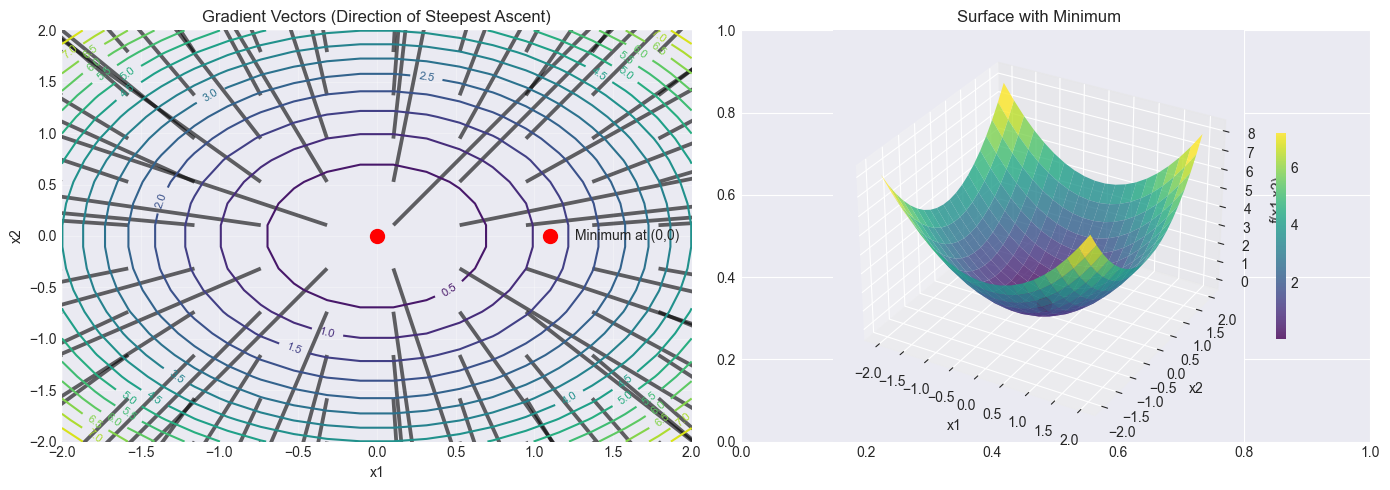

In [25]:
grads = torch.zeros_like(X1)         
grads2 = torch.zeros_like(X2)        

# Compute gradients at each point
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x = torch.tensor([X1[i, j].item(), X2[i, j].item()], requires_grad=True)
        y = f_2d(x[0], x[1])
        y.backward()                         # 400 times
        grads[i, j] = x.grad[0]
        grads2[i, j] = x.grad[1]

# Convert to numpy for visualization
X1_np = X1.detach().numpy()
X2_np = X2.detach().numpy()
Z = X1_np**2 + X2_np**2

grads_np = grads.numpy()
grads2_np = grads2.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contour = axes[0].contour(X1_np, X2_np, Z, levels=15, cmap='viridis')

axes[0].clabel(contour, inline=True, fontsize=8)

axes[0].quiver(X1_np[::2, ::2], X2_np[::2, ::2], grads_np[::2, ::2], grads2_np[::2, ::2], alpha=0.6, scale=0.5)     
axes[0].scatter(0, 0, color='red', s=100, label='Minimum at (0,0)')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].set_title('Gradient Vectors (Direction of Steepest Ascent)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 3D surface plot
ax = fig.add_subplot(122, projection='3d')
surf = ax.plot_surface(X1_np, X2_np, Z, cmap='viridis', alpha=0.8, linewidth=0)
ax.scatter([0], [0], [0], color='red', s=100, label='Minimum')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1,x2)')
ax.set_title('Surface with Minimum')
fig.colorbar(surf, ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

In [26]:
# PEDAGOGICAL ONLY — nested loop, for understanding.
# See next cell for vectorized version.

def f2d(x1, x2):
    return x1**2 + x2**2

g = torch.linspace(-2, 2, 20)
X1, X2 = torch.meshgrid(g, g, indexing='ij')
Z  = X1**2 + X2**2
Gx = torch.zeros_like(X1)
Gy = torch.zeros_like(X2)

for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        p = torch.tensor([X1[i, j].item(), X2[i, j].item()], requires_grad=True)
        s = f2d(p[0], p[1])
        s.backward()
        Gx[i, j] = p.grad[0]
        Gy[i, j] = p.grad[1]

print(f"Computed gradients at {X1.numel()} points using a nested loop.")

Computed gradients at 400 points using a nested loop.


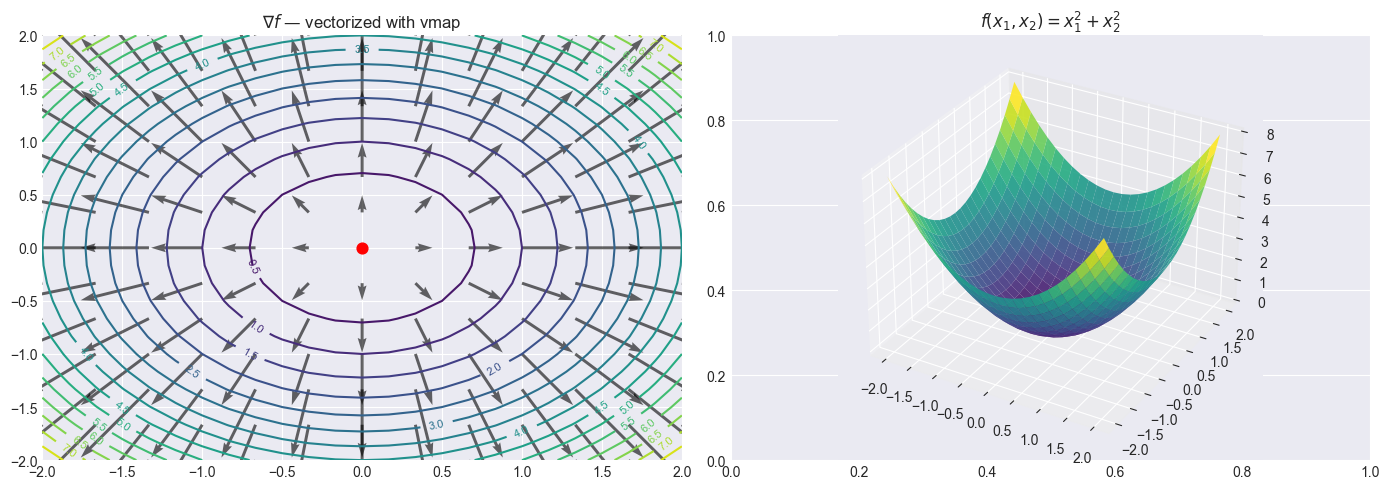

Gradient visualization complete!


In [27]:
# ----------------
# Gradient Vector Field — vectorized
# ---------------------

def f2d(p):
    return p[0]**2 + p[1]**2

grad_f = grad(f2d)                                    

g = torch.linspace(-2, 2, 25)
X1, X2 = torch.meshgrid(g, g, indexing='ij')
points = torch.stack([X1.flatten(), X2.flatten()], 1)  

grads = vmap(grad_f)(points)                           
Gx = grads[:, 0].reshape(X1.shape)
Gy = grads[:, 1].reshape(X2.shape)
Z  = X1**2 + X2**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
c = axes[0].contour(X1, X2, Z, levels=15, cmap='viridis')
axes[0].clabel(c, inline=True, fontsize=8)
axes[0].quiver(X1[::2, ::2], X2[::2, ::2],
               Gx[::2, ::2], Gy[::2, ::2],
               alpha=0.6, scale=25)
axes[0].scatter(0, 0, c='red', s=60, zorder=5)
axes[0].set(title=r'$\nabla f$ — vectorized with vmap')

ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.9, linewidth=0)
ax.set(title=r'$f(x_1,x_2) = x_1^2 + x_2^2$')
plt.tight_layout(); plt.show()
print("Gradient visualization complete!")

In [28]:
# ---------- CHAIN RULE & BACKPROPAGATION ----------

print("\n--- CHAIN RULE & BACKPROPAGATION ---")

x = torch.tensor(3.0, requires_grad=True)

a = x + 2
y = a ** 2
y.backward()

print(f"Computational graph: y = (x+2)²")
print(f"At x = {x.item():.1f}:")
print(f"a = x+2 = {a.item():.1f}")
print(f"y = a² = {y.item():.1f}")
print(f"dy/dx (computed by PyTorch): {x.grad.item():.2f}")
print(f"Analytical derivative: 2(x+2) = {2*(x.item()+2):.2f}")

# ---------- GRADIENT TAPE EQUIVALENT (Manual Backprop) ----------
print("\n--- MANUAL BACKPROPAGATION (DEMONSTRATION) ---")

def manual_backprop(x):
    """Demonstrate manual chain rule computation"""
    # Forward pass
    a = x + 2
    y = a ** 2
    
    # Manual backward pass (chain rule)
    dy_da = 2 * a
    da_dx = 1
    dy_dx = dy_da * da_dx
    
    return y, dy_dx

x_val = 3.0
y, dy_dx = manual_backprop(x_val)
print(f"At x = {x_val}:")
print(f"y = {y:.1f}")
print(f"dy/dx (manual) = {dy_dx:.1f}")
print(f"dy/dx (analytical) = {2*(x_val+2):.1f}")

# ---------- COMPUTATIONAL GRAPH VISUALIZATION ----------
print("\n--- COMPUTATIONAL GRAPH VISUALIZATION ---")

# Let's create a more complex computation graph
x1 = torch.tensor(2.0, requires_grad=True)
x2 = torch.tensor(3.0, requires_grad=True)

# Computation: y = x1² + 3*x2 + x1*x2
a = x1**2
b = 3*x2
c = x1*x2
y = a + b + c

# Compute gradients
y.backward()

print(f"x1 = {x1.item():.1f}, x2 = {x2.item():.1f}")
print(f"y = x1² + 3x2 + x1*x2 = {y.item():.1f}")
print(f"∂y/∂x1 = {x1.grad.item():.1f} (analytical: 2*x1 + x2 = {2*2 + 3:.1f})")
print(f"∂y/∂x2 = {x2.grad.item():.1f} (analytical: 3 + x1 = {3 + 2:.1f})")

print("\nPyTorch autograd handles all gradient computations automatically!")


--- CHAIN RULE & BACKPROPAGATION ---
Computational graph: y = (x+2)²
At x = 3.0:
a = x+2 = 5.0
y = a² = 25.0
dy/dx (computed by PyTorch): 10.00
Analytical derivative: 2(x+2) = 10.00

--- MANUAL BACKPROPAGATION (DEMONSTRATION) ---
At x = 3.0:
y = 25.0
dy/dx (manual) = 10.0
dy/dx (analytical) = 10.0

--- COMPUTATIONAL GRAPH VISUALIZATION ---
x1 = 2.0, x2 = 3.0
y = x1² + 3x2 + x1*x2 = 19.0
∂y/∂x1 = 7.0 (analytical: 2*x1 + x2 = 7.0)
∂y/∂x2 = 5.0 (analytical: 3 + x1 = 5.0)

PyTorch autograd handles all gradient computations automatically!



--- HESSIANS WITH PYTORCH ---
g shape: torch.Size([2])
g values: tensor([3.5000, 4.0000], grad_fn=<AddBackward0>)

f(x1,x2) = x1² + x2² + 3*x1*x2
At x = [1.  0.5]:
Hessian matrix H:
tensor([[2., 3.],
        [3., 2.]])
Eigenvalues: tensor([-1.,  5.])
Hessian describes local curvature - important for optimization


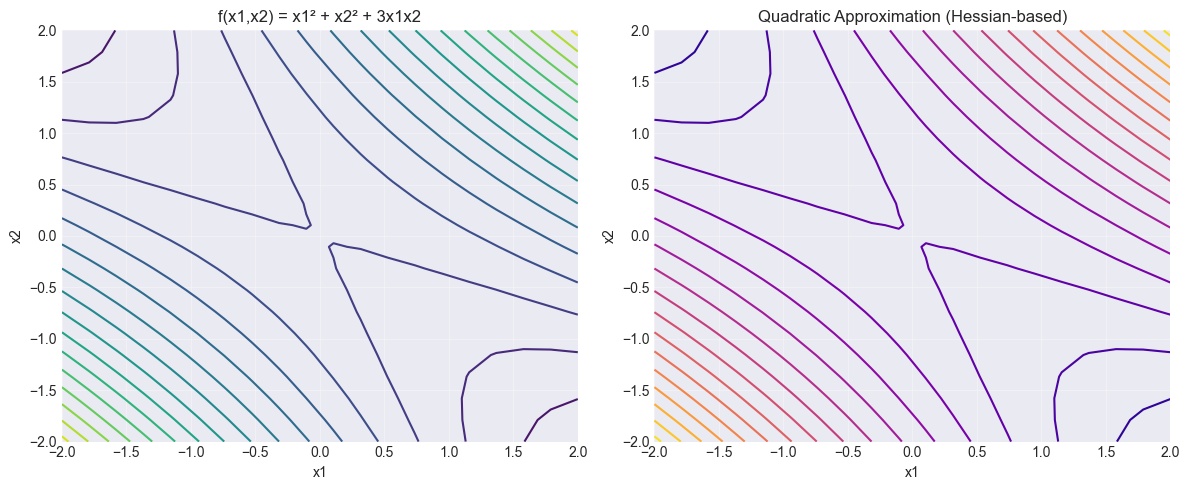

Because your original function f(x1,x2) = x1² + x2² + 3x1x2 was already a pure quadratic function with no higher powers (like x³), its Hessian-based
quadratic approximation is 100% identical to the real function. That is why both contour plots look exactly the same!

Hessian visualization complete!


In [29]:
# ---------- HESSIANS WITH PYTORCH ----------

print("\n--- HESSIANS WITH PYTORCH ---")

def f_hessian_torch(x):
    """f(x1,x2) = x1² + x2² + 3*x1*x2"""
    return x[0]**2 + x[1]**2 + 3*x[0]*x[1]

# Compute Hessian using PyTorch
x = torch.tensor([1.0, 0.5], requires_grad=True)

y = f_hessian_torch(x)
g = torch.autograd.grad(y, x, create_graph=True)[0]          
print(f"g shape: {g.shape}")
print(f"g values: {g}")
#print(f"g[0] : {g[0]} , g[1] : {g[1]}")

hess = torch.zeros((2, 2))
for i in range(2):
    for j in range(2):
        hess[i, j] = torch.autograd.grad(g[i], x, retain_graph=True)[0][j]         
        # print(f"hessian : {hess}")

print(f"\nf(x1,x2) = x1² + x2² + 3*x1*x2")
print(f"At x = {x.detach().numpy()}:")
print(f"Hessian matrix H:\n{hess}")

print(f"Eigenvalues: {torch.linalg.eigvalsh(hess)}")
print("Hessian describes local curvature - important for optimization")

# Visualize Hessian curvature
X_np = np.linspace(-2, 2, 20)
Y_np = np.linspace(-2, 2, 20)
X, Y = np.meshgrid(X_np, Y_np)
Z = X**2 + Y**2 + 3*X*Y               # f(x1,x2) = x1² + x2² + 3*x1*x2

H0 = torch.tensor([[2.0, 3.0], [3.0, 2.0]])
Z_approx = 0.5 * (H0[0,0]*X**2 + 2*H0[0,1]*X*Y + H0[1,1]*Y**2)        
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

contour1 = axes[0].contour(X, Y, Z, levels=15, cmap='viridis')
axes[0].set_title('f(x1,x2) = x1² + x2² + 3x1x2')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].grid(True, alpha=0.3)

contour2 = axes[1].contour(X, Y, Z_approx, levels=15, cmap='plasma')
axes[1].set_title('Quadratic Approximation (Hessian-based)')
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Because your original function f(x1,x2) = x1² + x2² + 3x1x2 was already a pure quadratic function with no higher powers (like x³), its Hessian-based\nquadratic approximation is 100% identical to the real function. That is why both contour plots look exactly the same!")
print("\nHessian visualization complete!")

In [30]:
# ----------------
# Hessian — vectorized
# PRODUCTION IDIOM
# --------------------

def f_hess(x):
    return x[0]**2 + x[1]**2 + 3*x[0]*x[1]

H = hessian(f_hess, torch.tensor([1.0, 0.5]))
print(f"H =\n{H}")
print(f"eigenvalues: {torch.linalg.eigvalsh(H).tolist()}")

H =
tensor([[2., 3.],
        [3., 2.]])
eigenvalues: [-1.0, 5.0]



--- PROBABILITY DISTRIBUTIONS ---


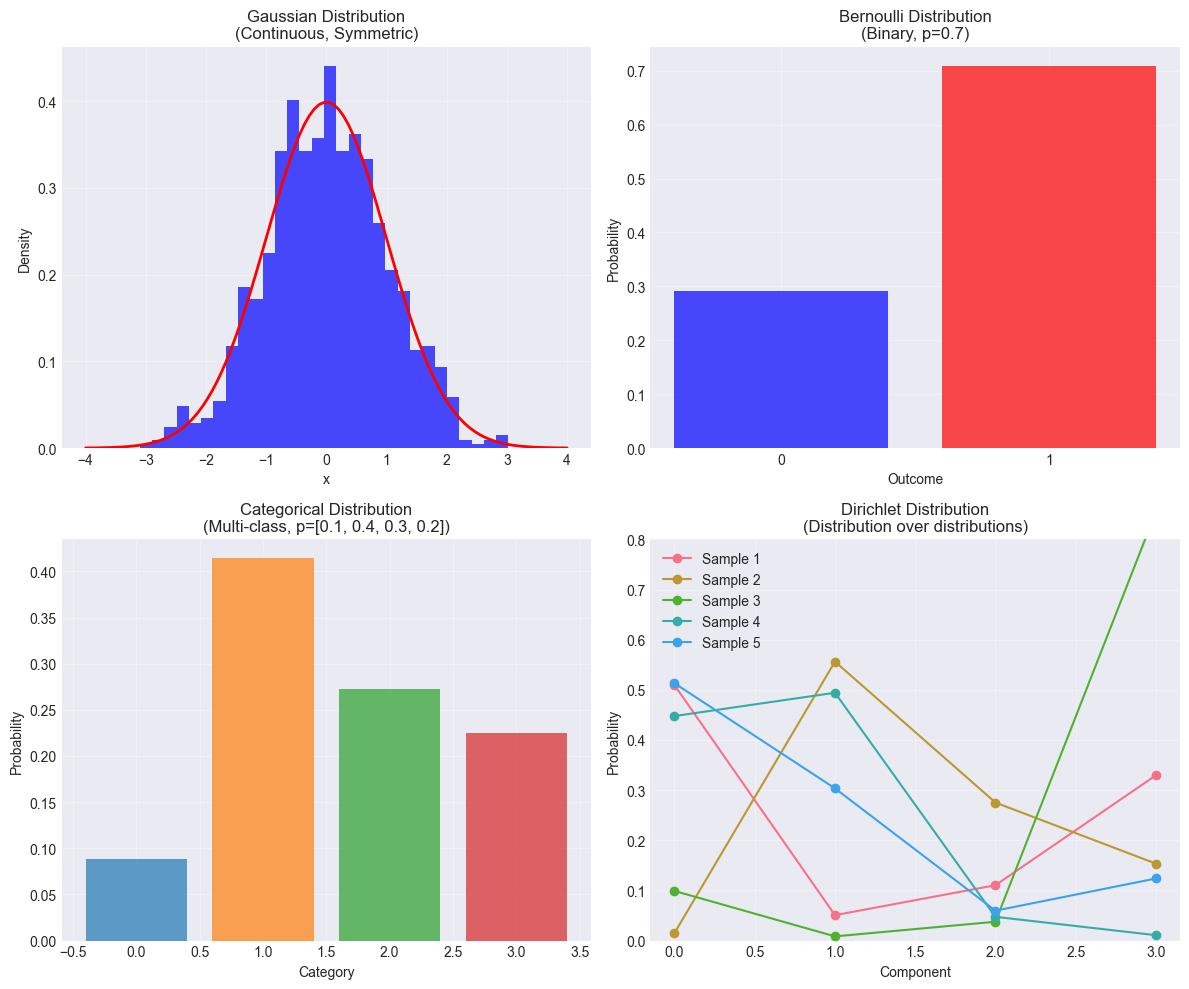

In [31]:
# ============================================================================
# 1.3 PROBABILITY & STATISTICS (PyTorch)
# ============================================================================

# ---------- PROBABILITY DISTRIBUTIONS ----------
print("\n--- PROBABILITY DISTRIBUTIONS ---")

torch.manual_seed(42)
n_samples = 1000

# Generate samples from different distributions
gaussian_samples = torch.randn(n_samples)               
bernoulli_samples = torch.bernoulli(torch.full((n_samples,), 0.7))             
categorical_samples = torch.multinomial(torch.tensor([0.1, 0.4, 0.3, 0.2]), n_samples, replacement=True)

dirichlet_dist = torch.distributions.Dirichlet(torch.tensor([1.0, 1.0, 1.0, 1.0]))         
dirichlet_samples = dirichlet_dist.sample((5,))

# Convert to numpy for plotting      
gaussian_np = gaussian_samples.numpy()                       # (1000,)
bernoulli_np = bernoulli_samples.numpy()                     # (1000,)
categorical_np = categorical_samples.numpy()                 # (1000,)
dirichlet_np = dirichlet_samples.numpy()                     # (5, 4)

# Plot distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gaussian
axes[0, 0].hist(gaussian_np, bins=30, density=True, alpha=0.7, color='blue')
x = np.linspace(-4, 4, 100)
axes[0, 0].plot(x, stats.norm.pdf(x, 0, 1), 'r-', linewidth=2)
axes[0, 0].set_title('Gaussian Distribution\n(Continuous, Symmetric)')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('Density')
axes[0, 0].grid(True, alpha=0.3)

# Bernoulli
axes[0, 1].bar([0, 1], [np.sum(bernoulli_np == 0)/n_samples, np.sum(bernoulli_np == 1)/n_samples],
               color=['blue', 'Red'], alpha=0.7)
axes[0, 1].set_title('Bernoulli Distribution\n(Binary, p=0.7)')
axes[0, 1].set_xlabel('Outcome')
axes[0, 1].set_ylabel('Probability')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].grid(True, alpha=0.3)

# Categorical
counts = [np.sum(categorical_np == c) for c in range(4)]

# Pass a list of 4 distinct colors instead of just 'green'
bar_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Standard blue, orange, green, red

axes[1, 0].bar(range(4), np.array(counts)/n_samples, alpha=0.7, color=bar_colors)
axes[1, 0].set_title('Categorical Distribution\n(Multi-class, p=[0.1, 0.4, 0.3, 0.2])')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Probability')
axes[1, 0].grid(True, alpha=0.3)

# Dirichlet
for i, sample in enumerate(dirichlet_np):
    axes[1, 1].plot(range(4), sample, 'o-', label=f'Sample {i+1}')
axes[1, 1].set_title('Dirichlet Distribution\n(Distribution over distributions)')
axes[1, 1].set_xlabel('Component')
axes[1, 1].set_ylabel('Probability')
axes[1, 1].set_ylim(0, 0.8)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

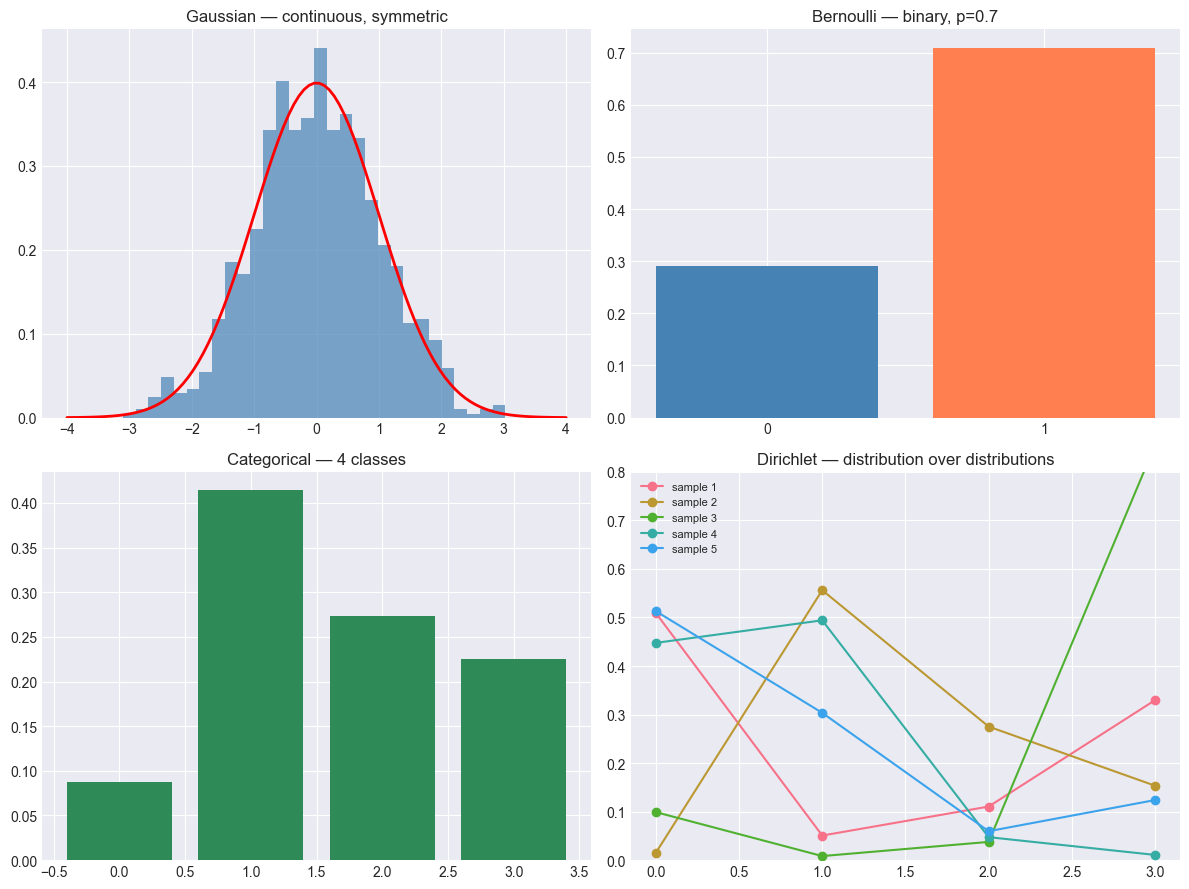

In [32]:
# ---------- PROBABILITY DISTRIBUTIONS ----------
torch.manual_seed(42)
n = 1000

gauss = torch.randn(n)
bern  = torch.bernoulli(torch.full((n,), 0.7))      
cat   = torch.multinomial(torch.tensor([0.1, 0.4, 0.3, 0.2]), n, replacement=True)
diri  = torch.distributions.Dirichlet(torch.ones(4)).sample((5,))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(gauss.numpy(), bins=30, density=True, alpha=0.7, color='steelblue')
xs = np.linspace(-4, 4, 100)
axes[0, 0].plot(xs, stats.norm.pdf(xs), 'r-', lw=2)
axes[0, 0].set_title('Gaussian — continuous, symmetric')

axes[0, 1].bar([0, 1], [(bern == 0).float().mean(), (bern == 1).float().mean()], color=['steelblue', 'coral'])
axes[0, 1].set_title('Bernoulli — binary, p=0.7'); axes[0, 1].set_xticks([0, 1])

counts = torch.bincount(cat, minlength=4).float() / n
axes[1, 0].bar(range(4), counts.numpy(), color='seagreen')
axes[1, 0].set_title('Categorical — 4 classes')

for i in range(5):
    axes[1, 1].plot(range(4), diri[i].numpy(), 'o-', label=f'sample {i+1}')
axes[1, 1].set_title('Dirichlet — distribution over distributions')
axes[1, 1].set_ylim(0, 0.8); axes[1, 1].legend(fontsize=8)

plt.tight_layout(); plt.show()

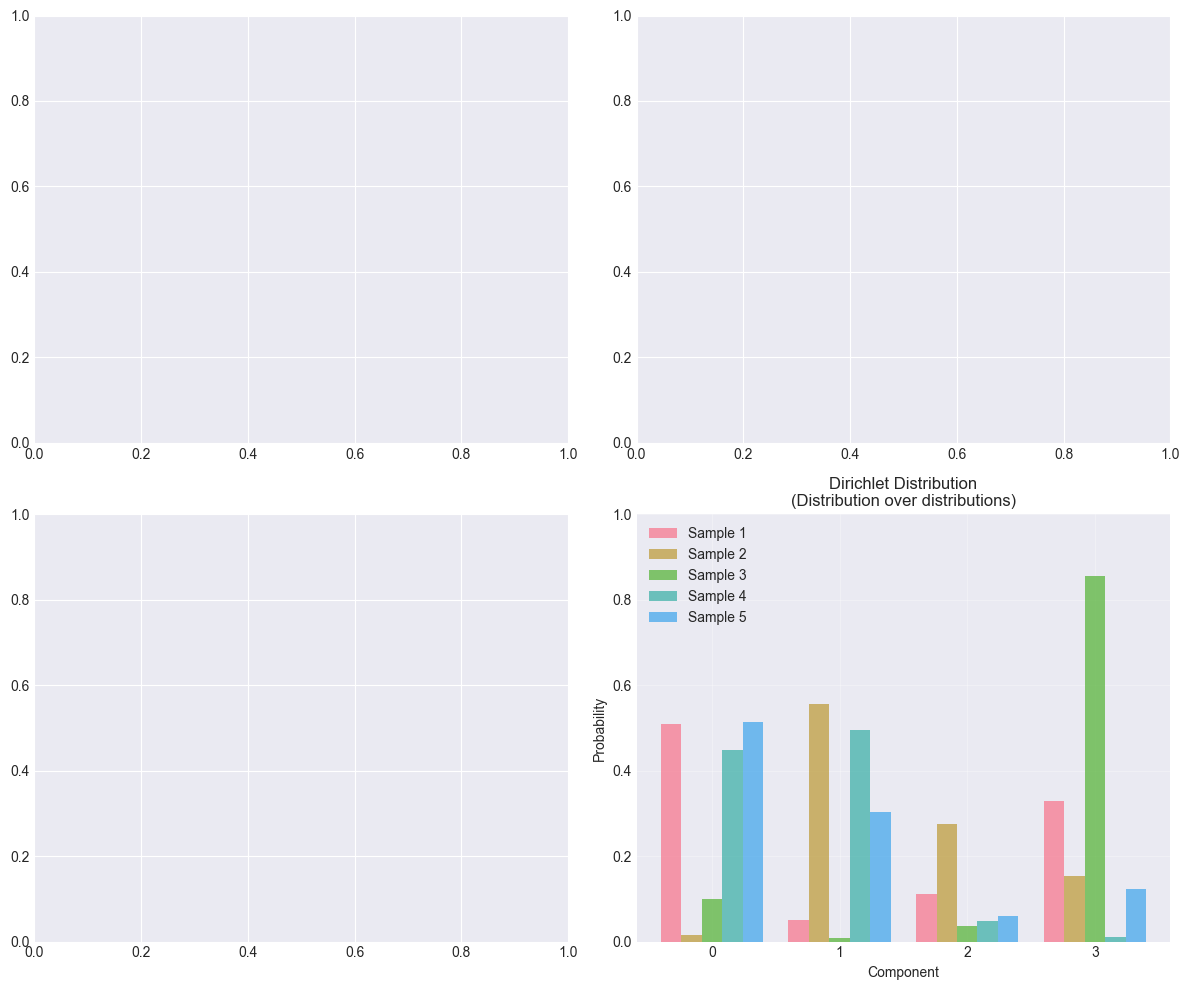

In [33]:
# Dirichlet - grouped bar chart
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Dirichlet - Grouped Bar Chart
total_samples = len(dirichlet_np)  
categories = np.arange(4)          

# Set the physical width of an individual bar
bar_width = 0.8 / total_samples

for i, sample in enumerate(dirichlet_np):    
    x_positions = categories + (i - total_samples / 2) * bar_width + (bar_width / 2)        
    axes[1, 1].bar(x_positions, sample, width=bar_width, alpha=0.7, label=f'Sample {i+1}')

axes[1, 1].set_title('Dirichlet Distribution\n(Distribution over distributions)')
axes[1, 1].set_xlabel('Component')
axes[1, 1].set_ylabel('Probability')

# Center the X-axis tick labels properly under each group of bars
axes[1, 1].set_xticks(categories)
axes[1, 1].set_xticklabels([f'{c}' for c in categories])

axes[1, 1].set_ylim(0, 1.0)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

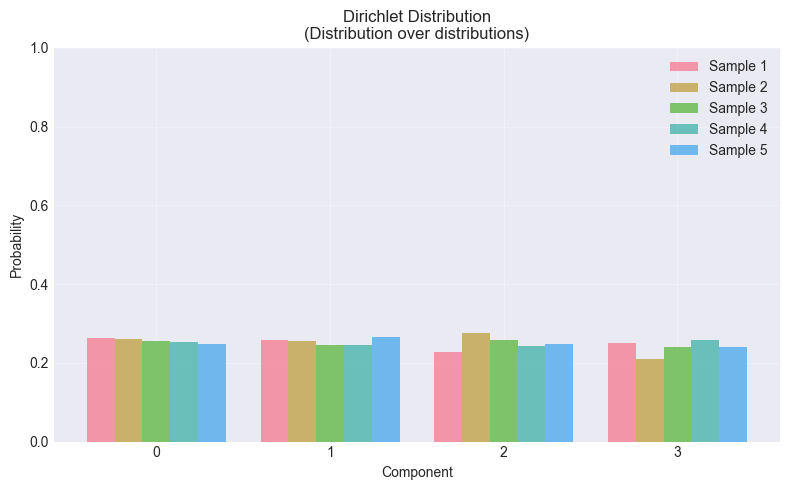

In [34]:
# A massive concentration value forces all samples to look identical -  alpha = [100, 100, 100, 100]
torch.manual_seed(42)

dirichlet_dist = torch.distributions.Dirichlet(torch.tensor([100.0, 100.0, 100.0, 100.0]))
dirichlet_samples = dirichlet_dist.sample((5,))
dirichlet_np = dirichlet_samples.numpy()

# Dirichlet - grouped bar chart
fig, axes = plt.subplots(figsize=(8, 5))

# Dirichlet - Grouped Bar Chart
total_samples = len(dirichlet_np)  
categories = np.arange(4)          

# Set the physical width of an individual bar
bar_width = 0.8 / total_samples

for i, sample in enumerate(dirichlet_np):
    x_positions = categories + (i - total_samples / 2) * bar_width + (bar_width / 2)
    axes.bar(x_positions, sample, width=bar_width, alpha=0.7, label=f'Sample {i+1}')

axes.set_title('Dirichlet Distribution\n(Distribution over distributions)')
axes.set_xlabel('Component')
axes.set_ylabel('Probability')

axes.set_xticks(categories)
axes.set_xticklabels([f'{c}' for c in categories])

axes.set_ylim(0, 1.0)
axes.grid(True, alpha=0.3)
axes.legend()

plt.tight_layout()
plt.show()

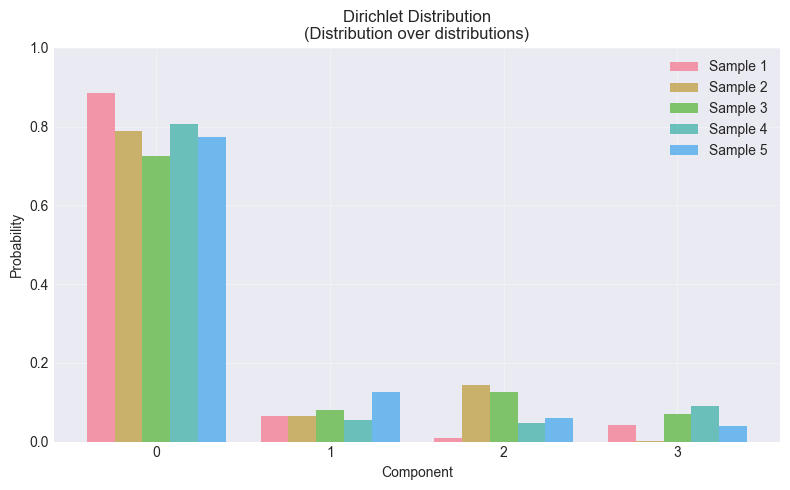

In [35]:
# If you set alpha = [10, 1, 1, 1], you are telling PyTorch: "I am highly confident that every 
# document must be mostly Topic 0." If you sample 5 documents here, they will all look very similar (all heavily favoring Topic 0).
torch.manual_seed(42)

dirichlet_dist = torch.distributions.Dirichlet(torch.tensor([10.0, 1.0, 1.0, 1.0]))
dirichlet_samples = dirichlet_dist.sample((5,))
dirichlet_np = dirichlet_samples.numpy()

# Dirichlet - grouped bar chart
fig, axes = plt.subplots(figsize=(8, 5))

# Dirichlet - Grouped Bar Chart
total_samples = len(dirichlet_np)  
categories = np.arange(4)          

# Set the physical width of an individual bar
bar_width = 0.8 / total_samples

for i, sample in enumerate(dirichlet_np):
    x_positions = categories + (i - total_samples / 2) * bar_width + (bar_width / 2)     
    axes.bar(x_positions, sample, width=bar_width, alpha=0.7, label=f'Sample {i+1}')

axes.set_title('Dirichlet Distribution\n(Distribution over distributions)')
axes.set_xlabel('Component')
axes.set_ylabel('Probability')

# Center the X-axis tick labels properly under each group of bars
axes.set_xticks(categories)
axes.set_xticklabels([f'{c}' for c in categories])

axes.set_ylim(0, 1.0)
axes.grid(True, alpha=0.3)
axes.legend()

plt.tight_layout()
plt.show()

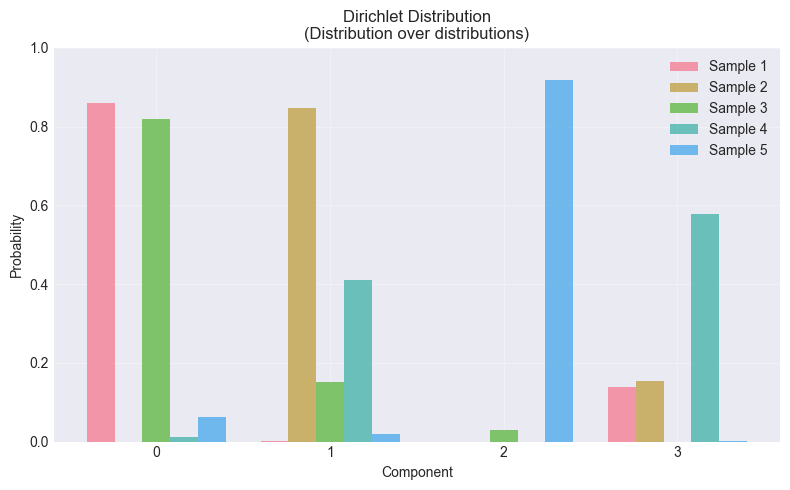

In [36]:
# When you set alpha = [0.1, 0.1, 0.1, 0.1], you create what is called a sparse Dirichlet distribution.

torch.manual_seed(42)

dirichlet_dist = torch.distributions.Dirichlet(torch.tensor([0.1, 0.1, 0.1, 0.1]))
dirichlet_samples = dirichlet_dist.sample((5,))
dirichlet_np = dirichlet_samples.numpy()

# Dirichlet - grouped bar chart
fig, axes = plt.subplots(figsize=(8, 5))

# Dirichlet - Grouped Bar Chart
total_samples = len(dirichlet_np)  
categories = np.arange(4)          

# Set the physical width of an individual bar
bar_width = 0.8 / total_samples

for i, sample in enumerate(dirichlet_np):
    # Calculate the X-offset shift for this specific sample group
    x_positions = categories + (i - total_samples / 2) * bar_width + (bar_width / 2)
    
    # Plot the bars for this sample
    axes.bar(x_positions, sample, width=bar_width, alpha=0.7, label=f'Sample {i+1}')

axes.set_title('Dirichlet Distribution\n(Distribution over distributions)')
axes.set_xlabel('Component')
axes.set_ylabel('Probability')

# Center the X-axis tick labels properly under each group of bars
axes.set_xticks(categories)
axes.set_xticklabels([f'{c}' for c in categories])

axes.set_ylim(0, 1.0)
axes.grid(True, alpha=0.3)
axes.legend()

plt.tight_layout()
plt.show()

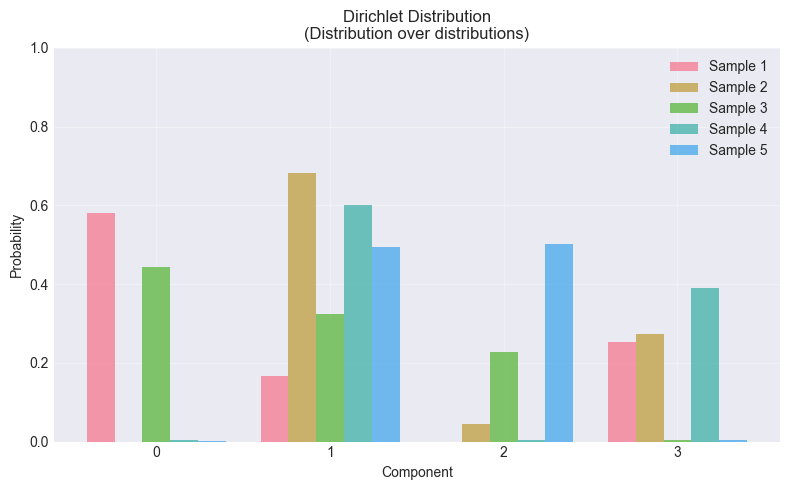

In [37]:
# alpha = [0.1, 0.4, 0.3, 0.2]

torch.manual_seed(42)

dirichlet_dist = torch.distributions.Dirichlet(torch.tensor([0.1, 0.4, 0.3, 0.2]))
dirichlet_samples = dirichlet_dist.sample((5,))
dirichlet_np = dirichlet_samples.numpy()

# Dirichlet - grouped bar chart
fig, axes = plt.subplots(figsize=(8, 5))

# Dirichlet - Grouped Bar Chart
total_samples = len(dirichlet_np)  
categories = np.arange(4)          

# Set the physical width of an individual bar
bar_width = 0.8 / total_samples

for i, sample in enumerate(dirichlet_np):
    # Calculate the X-offset shift for this specific sample group
    x_positions = categories + (i - total_samples / 2) * bar_width + (bar_width / 2)
    
    # Plot the bars for this sample
    axes.bar(x_positions, sample, width=bar_width, alpha=0.7, label=f'Sample {i+1}')

axes.set_title('Dirichlet Distribution\n(Distribution over distributions)')
axes.set_xlabel('Component')
axes.set_ylabel('Probability')

# Center the X-axis tick labels properly under each group of bars
axes.set_xticks(categories)
axes.set_xticklabels([f'{c}' for c in categories])

axes.set_ylim(0, 1.0)
axes.grid(True, alpha=0.3)
axes.legend()

plt.tight_layout()
plt.show()

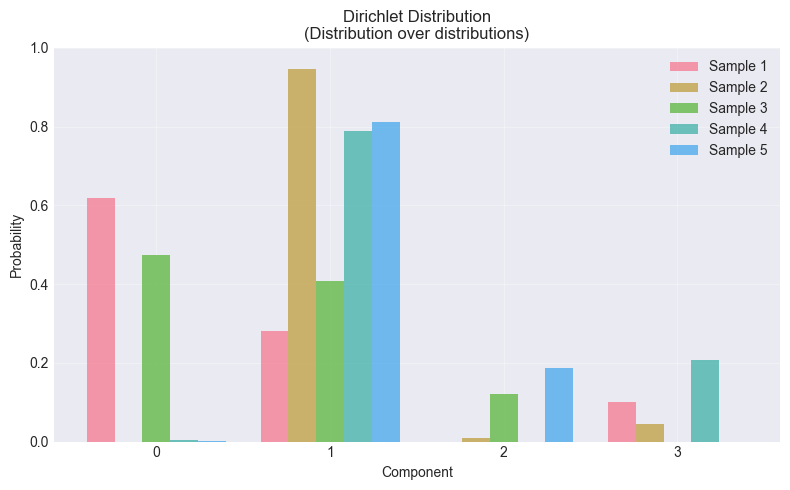

In [38]:
# alpha = [0.1, 0.5, 0.2, 0.1]

torch.manual_seed(42)

dirichlet_dist = torch.distributions.Dirichlet(torch.tensor([0.1, 0.5, 0.2, 0.1]))
dirichlet_samples = dirichlet_dist.sample((5,))
dirichlet_np = dirichlet_samples.numpy()

# Dirichlet - grouped bar chart
fig, axes = plt.subplots(figsize=(8, 5))

# Dirichlet - Grouped Bar Chart
total_samples = len(dirichlet_np)  
categories = np.arange(4)          

# Set the physical width of an individual bar
bar_width = 0.8 / total_samples

for i, sample in enumerate(dirichlet_np):    
    x_positions = categories + (i - total_samples / 2) * bar_width + (bar_width / 2)        
    axes.bar(x_positions, sample, width=bar_width, alpha=0.7, label=f'Sample {i+1}')

axes.set_title('Dirichlet Distribution\n(Distribution over distributions)')
axes.set_xlabel('Component')
axes.set_ylabel('Probability')

# Center the X-axis tick labels properly under each group of bars
axes.set_xticks(categories)
axes.set_xticklabels([f'{c}' for c in categories])

axes.set_ylim(0, 1.0)
axes.grid(True, alpha=0.3)
axes.legend()

plt.tight_layout()
plt.show()

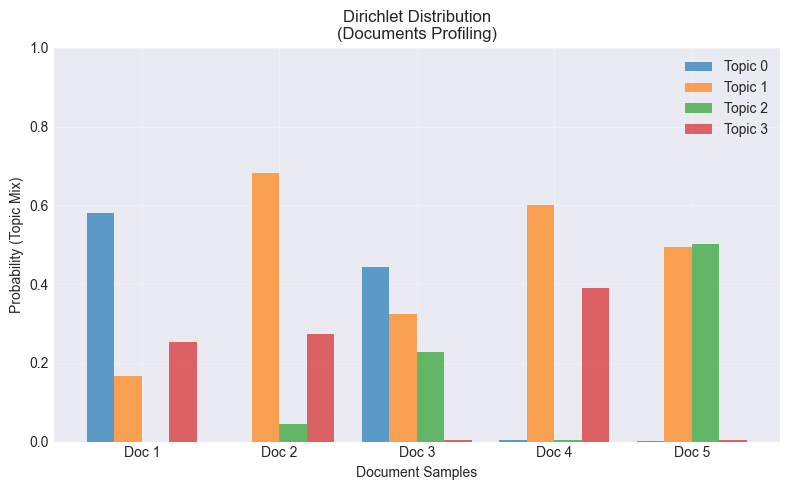

Distributions visualization complete!


In [39]:
# Dirichlet - Flipped Layout (Documents on X-axis, Colors as Topics)
# -----------------------------------------------------------------

torch.manual_seed(42)

# alpha = [0.1, 0.4, 0.3, 0.2]
dirichlet_dist = torch.distributions.Dirichlet(torch.tensor([0.1, 0.4, 0.3, 0.2]))
dirichlet_samples = dirichlet_dist.sample((5,))
dirichlet_np = dirichlet_samples.numpy()

# Dirichlet - grouped bar chart
fig, axes = plt.subplots(figsize=(8, 5))

# Dirichlet - Flipped Layout (Documents on X-axis, Colors as Topics)
total_samples = len(dirichlet_np)   
n_topics = dirichlet_np.shape[1]    

# Set the X positions for the 5 documents
doc_positions = np.arange(total_samples)

# Set the physical width of an individual bar
bar_width = 0.8 / n_topics

# 4 distinct colors for our 4 topics (Component 0 to 3)
topic_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  

for t in range(n_topics):    
    topic_values = dirichlet_np[:, t]    
    x_positions = doc_positions + (t - n_topics / 2) * bar_width + (bar_width / 2)    
    axes.bar(x_positions, topic_values, width=bar_width, alpha=0.7, 
                   color=topic_colors[t], label=f'Topic {t}')

axes.set_title('Dirichlet Distribution\n(Documents Profiling)')
axes.set_xlabel('Document Samples')
axes.set_ylabel('Probability (Topic Mix)')

# Center the X-axis labels perfectly under each document's cluster of bars
axes.set_xticks(doc_positions)
axes.set_xticklabels([f'Doc {i+1}' for i in doc_positions])

axes.set_ylim(0, 1.0)
axes.grid(True, alpha=0.3)

# Place the legend in the top right corner to show which color belongs to which topic
axes.legend(loc='upper right')

plt.tight_layout()
plt.show()
print("Distributions visualization complete!")

In [40]:
# ---------- EXPECTATION & VARIANCE ----------
print("\n--- EXPECTATION & VARIANCE ---")

torch.manual_seed(42)
data = torch.randn(10000) * 2 + 5                   

print(f"Data summary (Gaussian, μ=5, σ=2):")
print(f"Sample mean (empirical expectation): {data.mean().item():.4f}")
print(f"Sample variance: {data.var().item():.4f}")
print(f"Sample standard deviation: {data.std().item():.4f}")

def f_x_torch(x):
    return x**2

expected_f = f_x_torch(data).mean()
print(f"E[X²] = {expected_f.item():.4f}")                 
print(f"(Theoretical: Var(X) + (E[X])² = 4 + 25 = 29)")


--- EXPECTATION & VARIANCE ---
Data summary (Gaussian, μ=5, σ=2):
Sample mean (empirical expectation): 5.0129
Sample variance: 4.0358
Sample standard deviation: 2.0089
E[X²] = 29.1643
(Theoretical: Var(X) + (E[X])² = 4 + 25 = 29)


In [41]:
# ---------- CONDITIONAL PROBABILITY ----------
print("\n--- CONDITIONAL PROBABILITY ---")

# Example: Weather and activity data
torch.manual_seed(42)
n_days = 10000

is_rainy = torch.bernoulli(torch.full((n_days,), 0.3))     

stays_indoors = torch.where(                           
    is_rainy == 1,
    torch.bernoulli(torch.full((n_days,), 0.6)),       
    torch.bernoulli(torch.full((n_days,), 0.2))        
)

# Compute probabilities
P_rainy = is_rainy.float().mean().item()          
P_stays_indoors = stays_indoors.float().mean().item()         
P_rainy_and_indoors = ((is_rainy == 1) & (stays_indoors == 1)).float().mean().item()       
P_indoors_given_rainy = P_rainy_and_indoors / P_rainy

print("Weather and Activity Example:")
print(f"P(Rainy) = {P_rainy:.4f}")
print(f"P(Stays Indoors) = {P_stays_indoors:.4f}")
print(f"P(Rainy and Indoors) = {P_rainy_and_indoors:.4f}")
print(f"P(Indoors | Rainy) = {P_indoors_given_rainy:.4f}")
print(f"(Theoretical: 0.6)")


--- CONDITIONAL PROBABILITY ---
Weather and Activity Example:
P(Rainy) = 0.2988
P(Stays Indoors) = 0.3184
P(Rainy and Indoors) = 0.1830
P(Indoors | Rainy) = 0.6124
(Theoretical: 0.6)


In [42]:
# ---------- CONDITIONAL PROBABILITY ----------
n = 10_000
rainy = torch.bernoulli(torch.full((n,), 0.3))
indoors = torch.where(
    rainy.bool(),
    torch.bernoulli(torch.full((n,), 0.6)),
    torch.bernoulli(torch.full((n,), 0.2)),
)

p_r         = rainy.mean()
p_r_and_i   = (rainy * indoors).mean()
p_i_given_r = p_r_and_i / p_r
print(f"\nP(indoors | rainy) = {p_i_given_r.item():.4f}   (theory: 0.6)")


P(indoors | rainy) = 0.5927   (theory: 0.6)


In [43]:
# ---------- BAYES' THEOREM ----------

print("\n--- BAYES' THEOREM ---")

# Example: Medical testing using PyTorch
P_disease = torch.tensor(0.01)
P_no_disease = 1 - P_disease
P_positive_given_disease = torch.tensor(0.99)      
P_positive_given_no_disease = torch.tensor(0.05)

P_positive = (P_positive_given_disease * P_disease + 
              P_positive_given_no_disease * P_no_disease)

P_disease_given_positive = (P_positive_given_disease * P_disease) / P_positive

print("Medical Testing Example (Bayes' Theorem):")
print(f"P(Disease) = {P_disease.item()}")
print(f"P(Positive | Disease) = {P_positive_given_disease.item()}")
print(f"P(Positive | No Disease) = {P_positive_given_no_disease.item()}")
print(f"P(Positive) = {P_positive.item():.4f}")
print(f"P(Disease | Positive) = {P_disease_given_positive.item():.4f}")
print(f"Interpretation: Even with a positive test, probability of disease is {P_disease_given_positive.item():.1%}")


--- BAYES' THEOREM ---
Medical Testing Example (Bayes' Theorem):
P(Disease) = 0.009999999776482582
P(Positive | Disease) = 0.9900000095367432
P(Positive | No Disease) = 0.05000000074505806
P(Positive) = 0.0594
P(Disease | Positive) = 0.1667
Interpretation: Even with a positive test, probability of disease is 16.7%



--- MAXIMUM LIKELIHOOD ESTIMATION (PyTorch) ---
True parameters: μ=3.0, σ=1.5
MLE estimates from 1000 samples:
μ̂ = 3.0063
σ̂ = 1.5052


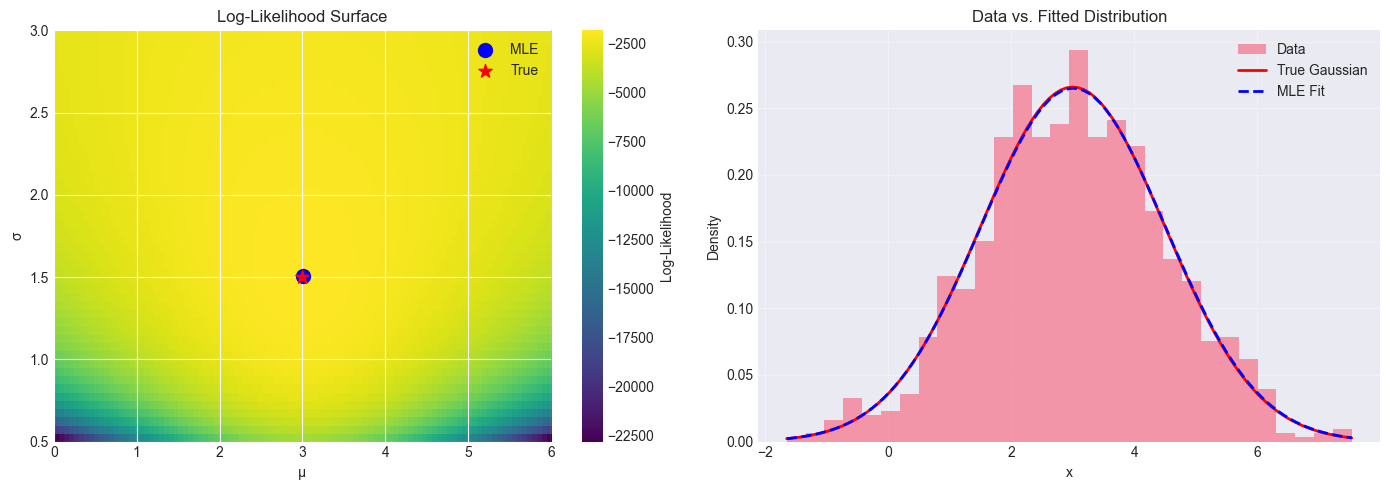

Maximizing the log-likelihood surface on the left produces a curve that perfectly hugs your actual dataset on the right.



In [44]:
# ---------- MAXIMUM LIKELIHOOD ESTIMATION ----------

print("\n--- MAXIMUM LIKELIHOOD ESTIMATION (PyTorch) ---")

torch.manual_seed(42)
true_mu = 3.0
true_sigma = 1.5
data = torch.normal(true_mu, true_sigma, size=(1000,))       

mle_mu = data.mean()
mle_sigma = data.std()

print(f"True parameters: μ={true_mu}, σ={true_sigma}")
print(f"MLE estimates from {len(data)} samples:")
print(f"μ̂ = {mle_mu.item():.4f}")
print(f"σ̂ = {mle_sigma.item():.4f}")

# Visualize likelihood
def gaussian_likelihood_torch(mu, sigma, data):
    """Compute log-likelihood of data under Gaussian(mu, sigma)"""
    n = len(data)
    return -n/2 * torch.log(torch.tensor(2*np.pi)) - n/2 * torch.log(sigma**2) - \
           1/(2*sigma**2) * torch.sum((data - mu)**2)

# Setting up a Parameter Search Grid
mu_range = torch.linspace(0, 6, 100)
sigma_range = torch.linspace(0.5, 3, 50)
likelihood = torch.zeros((len(mu_range), len(sigma_range)))

for i, mu in enumerate(mu_range):
    for j, sigma in enumerate(sigma_range):
        likelihood[i, j] = gaussian_likelihood_torch(mu, sigma, data)

likelihood_np = likelihood.numpy()
mu_np = mu_range.numpy()
sigma_np = sigma_range.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(likelihood_np.T, origin='lower', 
                    extent=[mu_np[0], mu_np[-1], sigma_np[0], sigma_np[-1]],
                    aspect='auto', cmap='viridis')
axes[0].scatter(mle_mu.item(), mle_sigma.item(), color='blue', s=100, marker='o', label='MLE')     
axes[0].scatter(true_mu, true_sigma, color='red', s=100, marker='*', label='True')    
axes[0].set_xlabel('μ')
axes[0].set_ylabel('σ')
axes[0].set_title('Log-Likelihood Surface')
axes[0].legend()

plt.colorbar(im, ax=axes[0], label='Log-Likelihood')
data_np = data.numpy()

axes[1].hist(data_np, bins=30, density=True, alpha=0.7, label='Data')
x_range = np.linspace(min(data_np), max(data_np), 100)

axes[1].plot(x_range, stats.norm.pdf(x_range, true_mu, true_sigma), 'r-', linewidth=2, label='True Gaussian')
axes[1].plot(x_range, stats.norm.pdf(x_range, mle_mu.item(), mle_sigma.item()), 
            'b--', linewidth=2, label='MLE Fit')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')
axes[1].set_title('Data vs. Fitted Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Maximizing the log-likelihood surface on the left produces a curve that perfectly hugs your actual dataset on the right.\n")

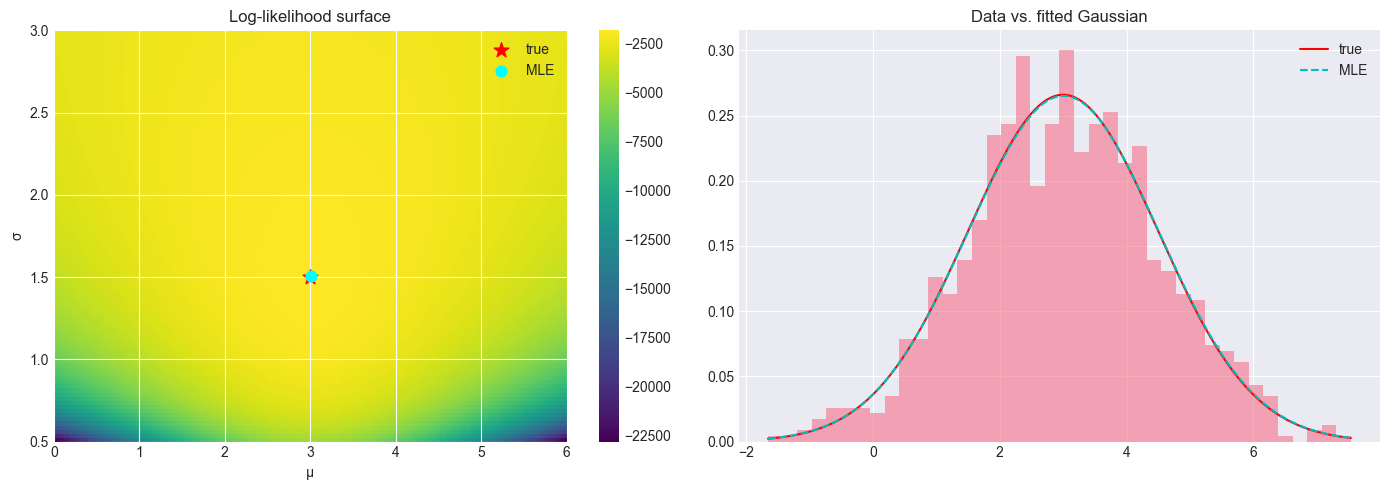

In [45]:
# -------------------
# MLE — log-likelihood surface, vectorized
# --------------------

torch.manual_seed(42)
n = 1000
true_mu, true_sigma = 3.0, 1.5
data = torch.randn(n) * true_sigma + true_mu

mu_range    = torch.linspace(0, 6, 150)
sigma_range = torch.linspace(0.5, 3, 100)
MU, SIGMA   = torch.meshgrid(mu_range, sigma_range, indexing='ij')   

diff = data - MU.unsqueeze(-1)                 
sq   = (diff**2).sum(dim=-1)                   

logL = (-0.5 * n * torch.log(torch.tensor(2 * torch.pi)) - n * torch.log(SIGMA) - 0.5 * sq / SIGMA**2)    

mu_hat, sigma_hat = data.mean().item(), data.std().item()              

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].imshow(logL.T, origin='lower', aspect='auto', cmap='viridis',
                    extent=[mu_range[0], mu_range[-1], sigma_range[0], sigma_range[-1]])
axes[0].scatter(true_mu, true_sigma, c='red',  marker='*', s=120, label='true')
axes[0].scatter(mu_hat, sigma_hat, c='cyan', marker='o', s=60,  label='MLE')
axes[0].set(xlabel='μ', ylabel='σ', title='Log-likelihood surface'); axes[0].legend()
plt.colorbar(im, ax=axes[0])

xs = torch.linspace(data.min(), data.max(), 200)
def gauss_pdf(x, mu, s): return torch.exp(-0.5*((x-mu)/s)**2) / (s*(2*torch.pi)**0.5)
axes[1].hist(data.numpy(), bins=40, density=True, alpha=0.6)
axes[1].plot(xs, gauss_pdf(xs, true_mu, true_sigma), 'r-',  label='true')
axes[1].plot(xs, gauss_pdf(xs, mu_hat, sigma_hat),  'c--', label='MLE')
axes[1].set(title='Data vs. fitted Gaussian'); axes[1].legend()
plt.tight_layout(); plt.show()

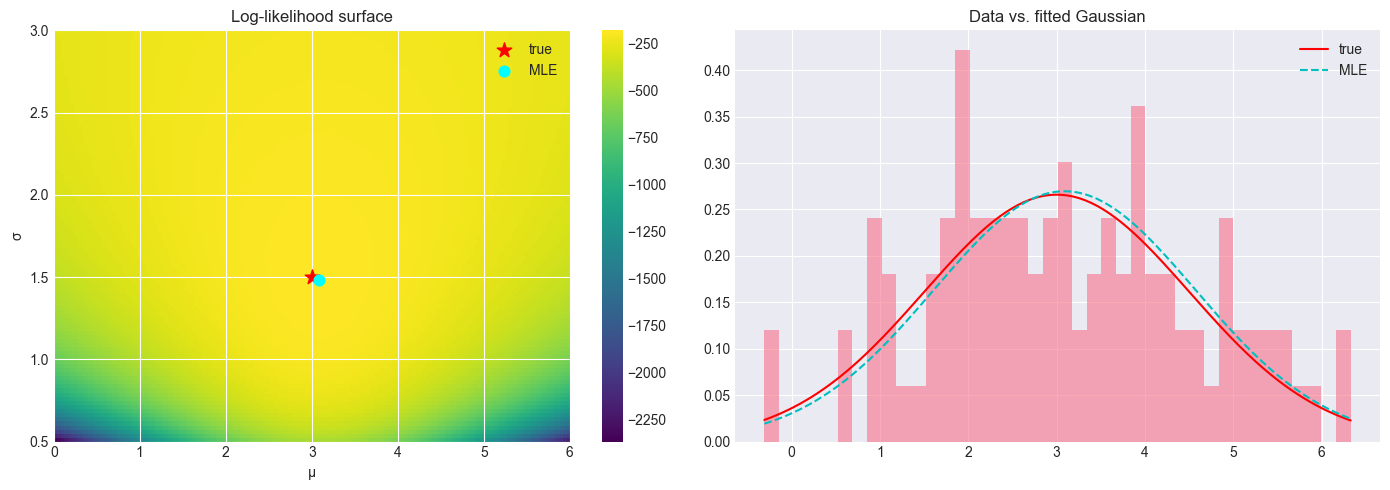

In [46]:
# -------------------------
# sample size set to 100 :
# -----------------------

torch.manual_seed(42)
n = 100
true_mu, true_sigma = 3.0, 1.5
data = torch.randn(n) * true_sigma + true_mu

mu_range    = torch.linspace(0, 6, 150)
sigma_range = torch.linspace(0.5, 3, 100)
MU, SIGMA   = torch.meshgrid(mu_range, sigma_range, indexing='ij')   


diff = data - MU.unsqueeze(-1)                 
sq   = (diff**2).sum(dim=-1)                   
logL = (-0.5 * n * torch.log(torch.tensor(2 * torch.pi)) - n * torch.log(SIGMA) - 0.5 * sq / SIGMA**2)    
mu_hat, sigma_hat = data.mean().item(), data.std().item()               

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].imshow(logL.T, origin='lower', aspect='auto', cmap='viridis',
                    extent=[mu_range[0], mu_range[-1], sigma_range[0], sigma_range[-1]])
axes[0].scatter(true_mu, true_sigma, c='red',  marker='*', s=120, label='true')
axes[0].scatter(mu_hat, sigma_hat, c='cyan', marker='o', s=60,  label='MLE')
axes[0].set(xlabel='μ', ylabel='σ', title='Log-likelihood surface'); axes[0].legend()
plt.colorbar(im, ax=axes[0])

xs = torch.linspace(data.min(), data.max(), 200)
def gauss_pdf(x, mu, s): return torch.exp(-0.5*((x-mu)/s)**2) / (s*(2*torch.pi)**0.5)
axes[1].hist(data.numpy(), bins=40, density=True, alpha=0.6)
axes[1].plot(xs, gauss_pdf(xs, true_mu, true_sigma), 'r-',  label='true')
axes[1].plot(xs, gauss_pdf(xs, mu_hat, sigma_hat),  'c--', label='MLE')
axes[1].set(title='Data vs. fitted Gaussian'); axes[1].legend()
plt.tight_layout(); plt.show()

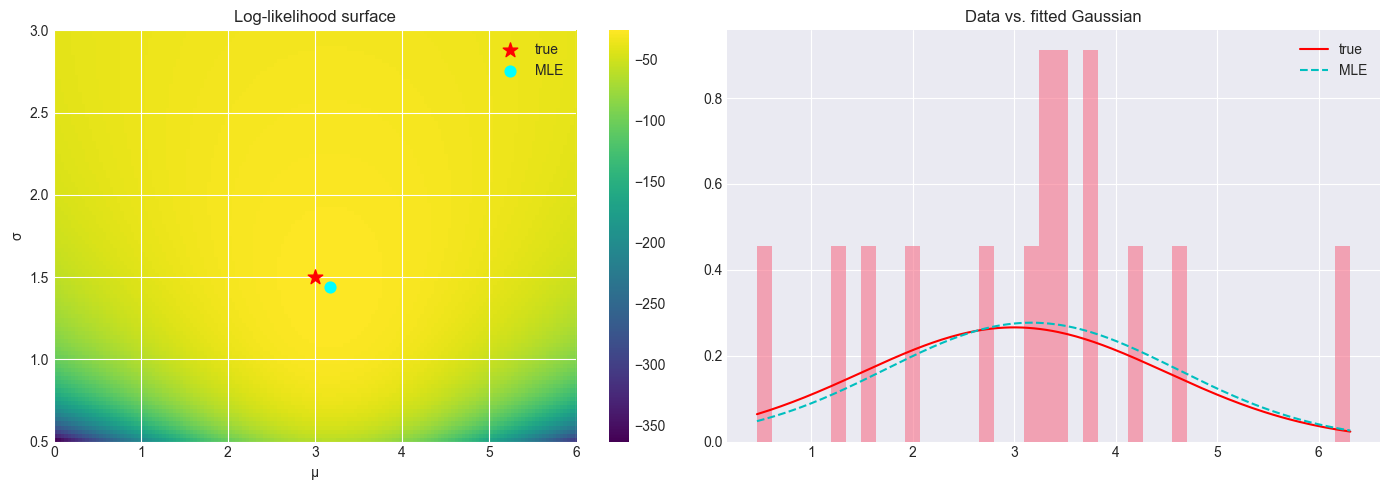

In [47]:
# -------------------------
# sample size set to 15 : an extreme shift to see it clearly
# -------------------------

torch.manual_seed(42)
n = 15
true_mu, true_sigma = 3.0, 1.5
data = torch.randn(n) * true_sigma + true_mu

mu_range    = torch.linspace(0, 6, 150)
sigma_range = torch.linspace(0.5, 3, 100)
MU, SIGMA   = torch.meshgrid(mu_range, sigma_range, indexing='ij')   


diff = data - MU.unsqueeze(-1)                 
sq   = (diff**2).sum(dim=-1)                   
logL = (-0.5 * n * torch.log(torch.tensor(2 * torch.pi)) - n * torch.log(SIGMA) - 0.5 * sq / SIGMA**2)    
mu_hat, sigma_hat = data.mean().item(), data.std().item()               

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].imshow(logL.T, origin='lower', aspect='auto', cmap='viridis',
                    extent=[mu_range[0], mu_range[-1], sigma_range[0], sigma_range[-1]])
axes[0].scatter(true_mu, true_sigma, c='red',  marker='*', s=120, label='true')
axes[0].scatter(mu_hat, sigma_hat, c='cyan', marker='o', s=60,  label='MLE')
axes[0].set(xlabel='μ', ylabel='σ', title='Log-likelihood surface'); axes[0].legend()
plt.colorbar(im, ax=axes[0])

xs = torch.linspace(data.min(), data.max(), 200)
def gauss_pdf(x, mu, s): return torch.exp(-0.5*((x-mu)/s)**2) / (s*(2*torch.pi)**0.5)
axes[1].hist(data.numpy(), bins=40, density=True, alpha=0.6)
axes[1].plot(xs, gauss_pdf(xs, true_mu, true_sigma), 'r-',  label='true')
axes[1].plot(xs, gauss_pdf(xs, mu_hat, sigma_hat),  'c--', label='MLE')
axes[1].set(title='Data vs. fitted Gaussian'); axes[1].legend()
plt.tight_layout(); plt.show()


--- MLE: GAUSSIAN ↔ MSE (PyTorch) ---



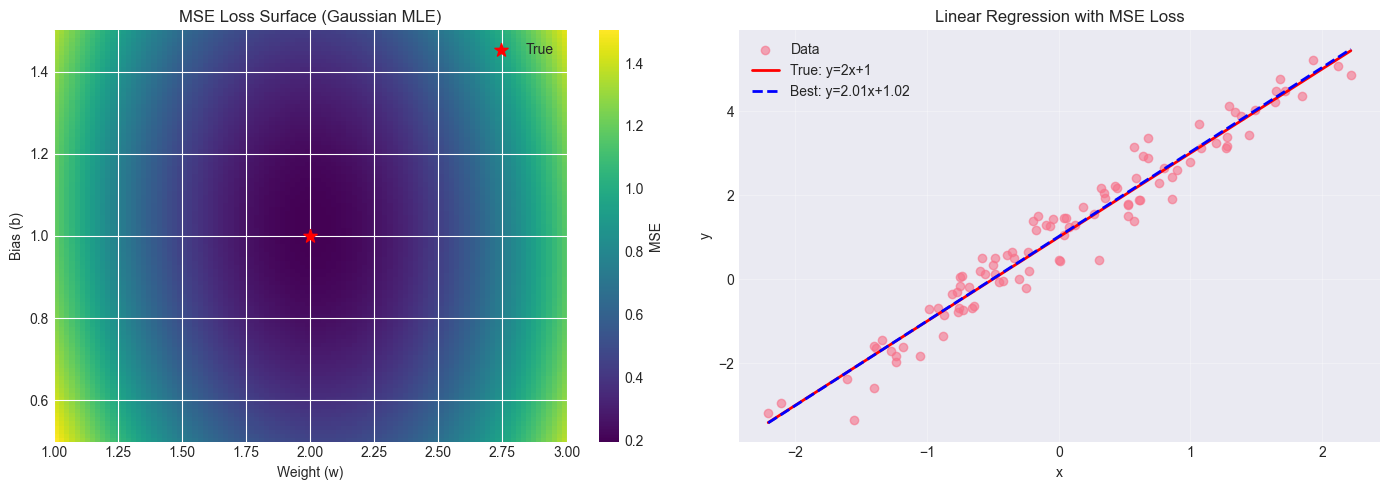

Just like the previous script, the dashed blue line (found purely by searching for the lowest MSE) will lay almost perfectly on top of the solid red line. This connects everything together: 
by looking for the line that minimizes the squared distances to the data points (MSE), you have seamlessly maximized the likelihood (MLE) of the underlying Gaussian distribution.

MLE vs MSE visualization complete!


In [48]:
# ---------- MLE: GAUSSIAN ↔ MSE ----------

print("\n--- MLE: GAUSSIAN ↔ MSE (PyTorch) ---\n")

# Demonstrate that Gaussian MLE is equivalent to minimizing MSE
torch.manual_seed(42)
X = torch.randn(100, 1)                         
y_true = 2 * X + 1 + 0.5 * torch.randn(100, 1)  

# Fit linear model using MSE
def mse_loss_torch(w, b, X, y):
    y_pred = X * w + b
    return torch.mean((y_pred - y)**2)

w_range = torch.linspace(1, 3, 100)
b_range = torch.linspace(0.5, 1.5, 100)
mse_grid = torch.zeros((len(w_range), len(b_range)))

for i, w in enumerate(w_range):
    for j, b in enumerate(b_range):
        mse_grid[i, j] = mse_loss_torch(w, b, X, y_true)         

# Convert to numpy for plotting
mse_np = mse_grid.numpy()
w_np = w_range.numpy()
b_np = b_range.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(mse_np.T, origin='lower', extent=[w_np[0], w_np[-1], b_np[0], b_np[-1]], aspect='auto', cmap='viridis')

axes[0].scatter(2, 1, color='red', s=100, marker='*', label='True')
axes[0].set_xlabel('Weight (w)')
axes[0].set_ylabel('Bias (b)')
axes[0].set_title('MSE Loss Surface (Gaussian MLE)')
axes[0].legend()
plt.colorbar(im, ax=axes[0], label='MSE')


# Data and best fit
best_idx = np.unravel_index(np.argmin(mse_np), mse_np.shape)
best_w = w_np[best_idx[0]]
best_b = b_np[best_idx[1]]

X_np = X.numpy()
y_np = y_true.numpy()
axes[1].scatter(X_np, y_np, alpha=0.6, label='Data')

x_line = np.linspace(X_np.min(), X_np.max(), 100)  
axes[1].plot(x_line, 2*x_line + 1, 'r-', linewidth=2, label='True: y=2x+1')
axes[1].plot(x_line, best_w*x_line + best_b, 'b--', linewidth=2, label=f'Best: y={best_w:.2f}x+{best_b:.2f}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Linear Regression with MSE Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Just like the previous script, the dashed blue line (found purely by searching for the lowest MSE) will lay almost perfectly on top of the solid red line. This connects everything together: \nby looking for the line that minimizes the squared distances to the data points (MSE), you have seamlessly maximized the likelihood (MLE) of the underlying Gaussian distribution.")
print("\nMLE vs MSE visualization complete!")


--- ENTROPY ---
Entropy of uniform over 1000 classes: 6.9078 nats
Entropy of uniform over 10 classes:   2.3026 nats
Entropy of peaked distribution:       0.2007 nats
Entropy of one-hot (certain):         -0.0000 nats

Theoretical max entropy for 1000 classes: log(1000) = 6.9078
High entropy = high uncertainty; low entropy = confident prediction


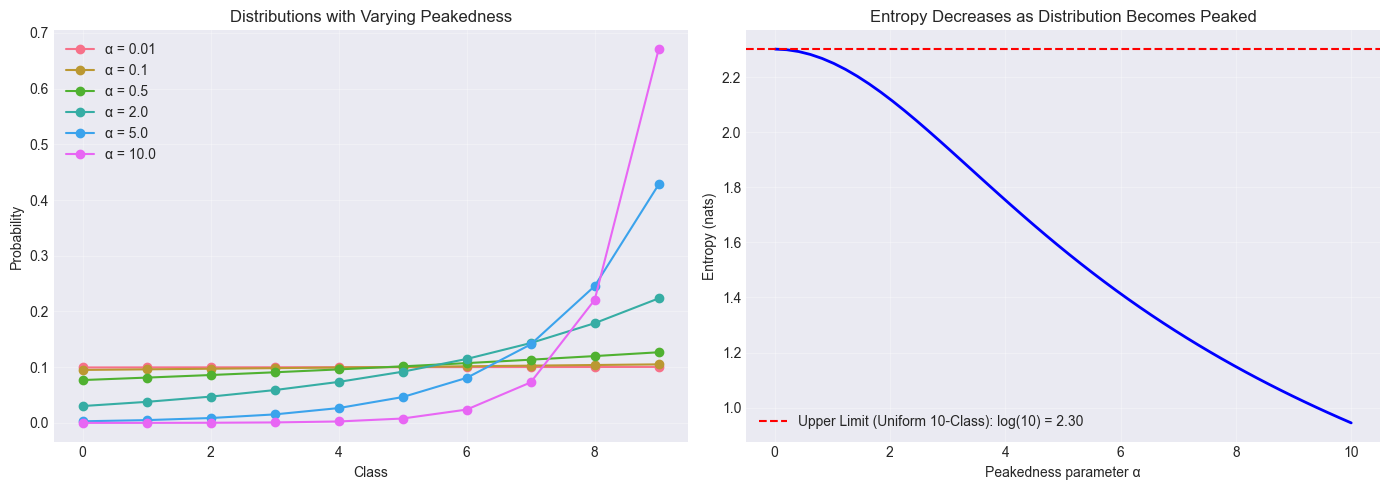

alpha = 0.01 : All 10 probabilities are nearly identical (approx 0.10), yielding maximum entropy (approx 2.30).
PyTorch tensor containing 10 probabilities that are nearly perfectly uniform:
	tensor([0.099501, 0.099611, 0.099722, 0.099833, 0.099944, 0.100055, 0.100166, 0.100278, 0.100389, 0.100501])
	Entropy : 2.30258

alpha = 10.0 : Class 9 dominates with 67% of the probability (and Class 8 takes 22%), while Class 0 drops to 0.003%, yielding low entropy (approx 0.96).
PyTorch tensor containing 10 probabilities heavily skewed toward the final index:
	tensor([0.000030, 0.000093, 0.000281, 0.000854, 0.002593, 0.007878, 0.023931, 0.072695, 0.220828, 0.670817])
	Entropy : 0.94436

Entropy visualization complete!


In [49]:
# ============================================================================
# 1.4 INFORMATION THEORY (PyTorch)
# ============================================================================

# ---------- ENTROPY ----------
print("\n--- ENTROPY ---")

torch.manual_seed(42)

def entropy_torch(p):
    """Compute entropy H(X) = -Σ p(x) log p(x) using PyTorch"""
    p = torch.as_tensor(p, dtype=torch.float32)                                
    mask = p > 0
    return -torch.sum(p[mask] * torch.log(p[mask]))      

# Compare entropies of different distributions
uniform_1000 = torch.ones(1000) / 1000                                 
uniform_10 = torch.ones(10) / 10                                       
peaked = torch.tensor([0.97] + [0.03/9]*9)                             
one_hot = torch.tensor([1.0, 0.0, 0.0, 0.0, 0.0])                      

print(f"Entropy of uniform over 1000 classes: {entropy_torch(uniform_1000).item():.4f} nats")
print(f"Entropy of uniform over 10 classes:   {entropy_torch(uniform_10).item():.4f} nats")
print(f"Entropy of peaked distribution:       {entropy_torch(peaked).item():.4f} nats")
print(f"Entropy of one-hot (certain):         {entropy_torch(one_hot).item():.4f} nats")
print(f"\nTheoretical max entropy for 1000 classes: log(1000) = {torch.log(torch.tensor(1000.0)).item():.4f}")
print("High entropy = high uncertainty; low entropy = confident prediction")

# Visualize entropy vs. peakedness
n_classes = 10

alphas = np.linspace(0.01, 10, 50)            
entropies = []

for alpha in alphas:                               
    probs = torch.softmax(torch.linspace(0, alpha, n_classes), dim=0)      
    entropies.append(entropy_torch(probs).item())                          

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

example_alphas = [0.01, 0.1, 0.5, 2.0, 5.0, 10.0]
for alpha in example_alphas:
    probs = torch.softmax(torch.linspace(0, alpha, n_classes), dim=0).numpy()
    axes[0].plot(range(n_classes), probs, 'o-', label=f'α = {alpha}')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Probability')
axes[0].set_title('Distributions with Varying Peakedness')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot entropy vs. alpha
axes[1].plot(alphas, entropies, 'b-', linewidth=2)
axes[1].axhline(y=np.log(n_classes), color='r', linestyle='--', label=f'Upper Limit (Uniform 10-Class): log({n_classes}) = {np.log(n_classes):.2f}')
axes[1].set_xlabel('Peakedness parameter α')
axes[1].set_ylabel('Entropy (nats)')
axes[1].set_title('Entropy Decreases as Distribution Becomes Peaked')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("alpha = 0.01 : All 10 probabilities are nearly identical (approx 0.10), yielding maximum entropy (approx 2.30).")
print("PyTorch tensor containing 10 probabilities that are nearly perfectly uniform:")
print("\ttensor([0.099501, 0.099611, 0.099722, 0.099833, 0.099944, 0.100055, 0.100166, 0.100278, 0.100389, 0.100501])")
print("\tEntropy : 2.30258")
print("\nalpha = 10.0 : Class 9 dominates with 67% of the probability (and Class 8 takes 22%), while Class 0 drops to 0.003%, yielding low entropy (approx 0.96).")
print("PyTorch tensor containing 10 probabilities heavily skewed toward the final index:")
print("\ttensor([0.000030, 0.000093, 0.000281, 0.000854, 0.002593, 0.007878, 0.023931, 0.072695, 0.220828, 0.670817])")
print("\tEntropy : 0.94436")
print("\nEntropy visualization complete!")



--- CROSS-ENTROPY ---
True label (one-hot): class 2
Cross-entropy with GOOD prediction (0.80 on true class):     0.2231
Cross-entropy with OKAY prediction (0.50 on true class):     0.6931
Cross-entropy with BAD prediction (0.20 on true class):      1.6094
Cross-entropy with TERRIBLE prediction (0.05 on true class): 2.9957

For one-hot labels: H(p, q) = -log(q_true_class)
q_true = [0.8  0.5  0.2  0.05] → -log(q_true) = [0.2231 0.6931 1.6094 2.9957]

Manual cross-entropy:            0.2231
torch.nn.CrossEntropyLoss:       0.2231

They match! CrossEntropyLoss = log_softmax + NLLLoss internally



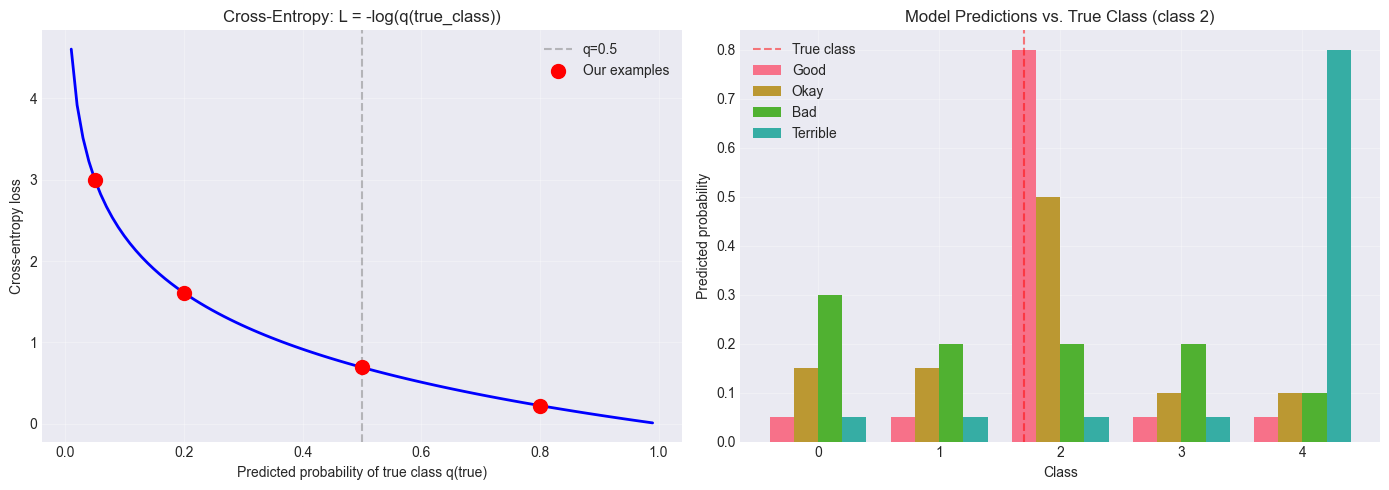

Left Subplot : Plots L = -ln(q_true) from 0.01 to 0.99. It overlays red scatter points corresponding to the 4 evaluated examples, illustrating how loss skyrockets as q_true -> 0.

Right Subplot: Displays a grouped bar chart comparing the class probability distributions across all 4 predictions relative to the true class 2 indicator line.

Cross-entropy visualization complete!


In [50]:
# ---------- CROSS-ENTROPY ----------
print("\n--- CROSS-ENTROPY ---")

torch.manual_seed(42)

def cross_entropy_torch(p, q):
    """Compute cross-entropy H(p, q) = -Σ p(x) log q(x) using PyTorch"""
    p = torch.as_tensor(p, dtype=torch.float32)
    q = torch.as_tensor(q, dtype=torch.float32)
    # Clip q to avoid log(0)
    q = torch.clamp(q, min=1e-12)
    return -torch.sum(p * torch.log(q))

# True distribution (one-hot label: class 2)
true_label = torch.tensor([0.0, 0.0, 1.0, 0.0, 0.0])

# Model predictions with varying quality
good_pred = torch.tensor([0.05, 0.05, 0.80, 0.05, 0.05])
okay_pred = torch.tensor([0.15, 0.15, 0.50, 0.10, 0.10])
bad_pred = torch.tensor([0.30, 0.20, 0.20, 0.20, 0.10])
terrible_pred = torch.tensor([0.05, 0.05, 0.05, 0.05, 0.80])  # Wrong class!

print("True label (one-hot): class 2")
print(f"Cross-entropy with GOOD prediction (0.80 on true class):     {cross_entropy_torch(true_label, good_pred).item():.4f}")
print(f"Cross-entropy with OKAY prediction (0.50 on true class):     {cross_entropy_torch(true_label, okay_pred).item():.4f}")
print(f"Cross-entropy with BAD prediction (0.20 on true class):      {cross_entropy_torch(true_label, bad_pred).item():.4f}")
print(f"Cross-entropy with TERRIBLE prediction (0.05 on true class): {cross_entropy_torch(true_label, terrible_pred).item():.4f}")

print("\nFor one-hot labels: H(p, q) = -log(q_true_class)")

q_true = torch.tensor([0.80, 0.50, 0.20, 0.05])                      
print(f"q_true = {q_true.numpy()} → -log(q_true) = {(-torch.log(q_true)).numpy().round(4)}")

logits = torch.log(good_pred).unsqueeze(0)  
target = torch.tensor([2])  
loss_fn = torch.nn.CrossEntropyLoss()
pytorch_loss = loss_fn(logits, target)

print(f"\nManual cross-entropy:            {cross_entropy_torch(true_label, good_pred).item():.4f}")
print(f"torch.nn.CrossEntropyLoss:       {pytorch_loss.item():.4f}")
print("\nThey match! CrossEntropyLoss = log_softmax + NLLLoss internally\n")

# Visualize cross-entropy vs. predicted probability of true class
q_true_range = np.linspace(0.01, 0.99, 100)
ce_values = -np.log(q_true_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cross-entropy curve
axes[0].plot(q_true_range, ce_values, 'b-', linewidth=2)
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='q=0.5')
axes[0].scatter([0.80, 0.50, 0.20, 0.05], 
                [-np.log(0.80), -np.log(0.50), -np.log(0.20), -np.log(0.05)],
                color='red', s=100, zorder=5, label='Our examples')
axes[0].set_xlabel('Predicted probability of true class q(true)')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Cross-Entropy: L = -log(q(true_class))')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Comparison of predictions
predictions = {
    'Good': good_pred.numpy(),
    'Okay': okay_pred.numpy(),
    'Bad': bad_pred.numpy(),
    'Terrible': terrible_pred.numpy()
}
x_pos = np.arange(5)
width = 0.2
for i, (name, pred) in enumerate(predictions.items()):
    axes[1].bar(x_pos + i*width, pred, width, label=name)
axes[1].axvline(x=2, color='red', linestyle='--', alpha=0.5, label='True class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Predicted probability')
axes[1].set_title('Model Predictions vs. True Class (class 2)')
axes[1].set_xticks(x_pos + 1.5*width)
axes[1].set_xticklabels(range(5))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Left Subplot : Plots L = -ln(q_true) from 0.01 to 0.99. It overlays red scatter points corresponding to the 4 evaluated examples, illustrating how loss skyrockets as q_true -> 0.")
print("\nRight Subplot: Displays a grouped bar chart comparing the class probability distributions across all 4 predictions relative to the true class 2 indicator line.")
print("\nCross-entropy visualization complete!")


--- KL DIVERGENCE ---
KL Divergence Examples:
p          = [0.1 0.4 0.3 0.2]
q_close    = [0.12 0.38 0.3  0.2 ]
q_far      = [0.25 0.25 0.25 0.25]

KL(p || q_close) = 0.002285  (small → similar)
KL(p || q_far)   = 0.106440  (larger → different)

--- KL DIVERGENCE IS NOT SYMMETRIC ---
p = [0.5 0.5 0. ]
q = [0.25 0.25 0.5 ]
KL(p || q) = 0.6931
KL(q || p) = 13.1224  (much larger!)

Interpretation:
  KL(p||q) is 'zero-avoiding': q must cover everywhere p > 0
  KL(q||p) is 'zero-forcing':  q must be 0 wherever p is 0
  This asymmetry drives different behaviors in VAEs and GANs

Manual KL(p || q_close) = 0.002285
F.kl_div equivalent     = 0.002285



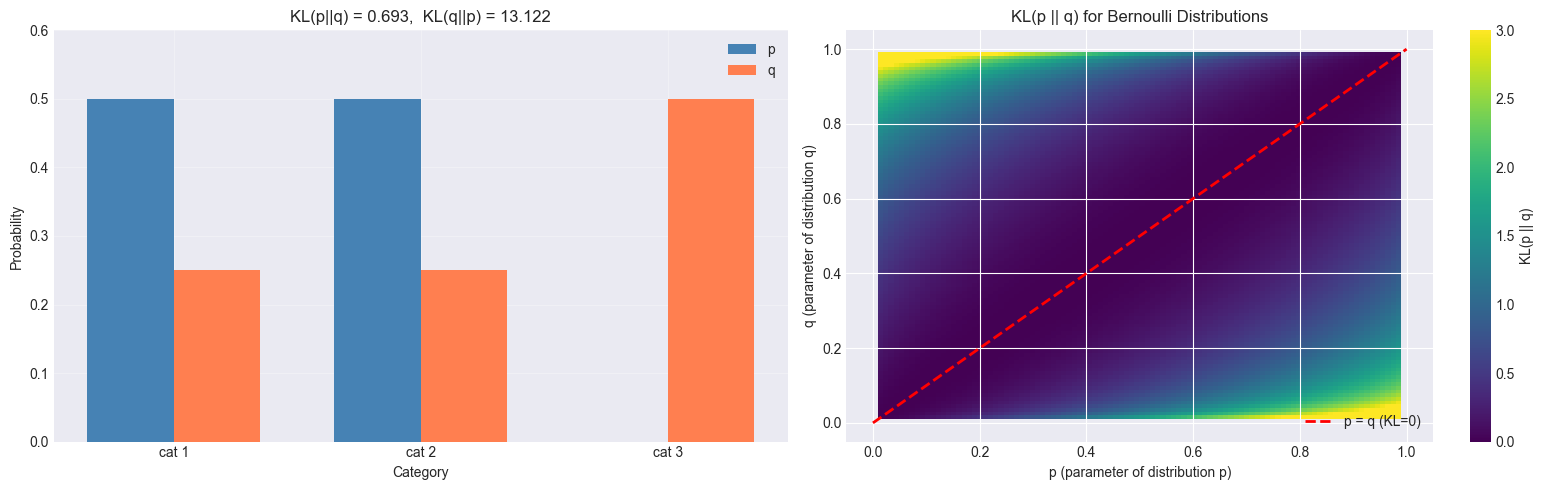

The Baseline Diagonal (p = q): A straight, red dashed line cuts diagonally across the center from (0,0) to (1,1). Along this exact path, the true distribution perfectly matches the predicted 
distribution. Because P = Q, the KL Divergence is exactly 0, creating a dark purple 'valley of perfection' running through the plot.

The Color Gradient (Varying Penalties): The colors transition based on your vmax=3 colorbar window:
	Dark Purple / Blue: Indicates very low divergence (values close to 0). This occurs near the diagonal where your predictions are highly accurate.
	Green / Yellow: Indicates higher divergence and a severe loss penalty. This happens as you move far away from the red line.

The Asymmetric Vertical Walls: The yellow 'cliffs' of high divergence are completely asymmetric:
	As your predictions approach the absolute boundaries (q -> 0 or q -> 1) while the true distribution p expects an event to happen, the chart violently spikes to bright yellow.
	This is the visual manifesta

In [51]:
# ---------- KL DIVERGENCE ----------
print("\n--- KL DIVERGENCE ---")

torch.manual_seed(42)

def kl_divergence_torch(p, q):
    """Compute KL(p || q) = Σ p(x) log(p(x)/q(x)) using PyTorch"""
    p = torch.as_tensor(p, dtype=torch.float32)
    q = torch.as_tensor(q, dtype=torch.float32)    
    mask = p > 0
    return torch.sum(p[mask] * torch.log(p[mask] / q[mask]))

# Example distributions
p = torch.tensor([0.1, 0.4, 0.3, 0.2])
q_close = torch.tensor([0.12, 0.38, 0.30, 0.20])  
q_far = torch.tensor([0.25, 0.25, 0.25, 0.25])    

kl_p_q_close = kl_divergence_torch(p, q_close)
kl_p_q_far = kl_divergence_torch(p, q_far)

print("KL Divergence Examples:")
print(f"p          = {p.numpy()}")
print(f"q_close    = {q_close.numpy()}")
print(f"q_far      = {q_far.numpy()}")
print(f"\nKL(p || q_close) = {kl_p_q_close.item():.6f}  (small → similar)")
print(f"KL(p || q_far)   = {kl_p_q_far.item():.6f}  (larger → different)")

# ---------- ASYMMETRY OF KL DIVERGENCE ----------
print("\n--- KL DIVERGENCE IS NOT SYMMETRIC ---")

# Case 1: KL(p || q) — zero-avoiding: penalizes q placing 0 where p > 0
p1 = torch.tensor([0.5, 0.5, 0.0])
q1 = torch.tensor([0.25, 0.25, 0.5])

# KL(p || q): p has zero at index 2, so that term is 0.
kl_pq = kl_divergence_torch(p1, q1)

# KL(q || p): q has 0.5 at index 2, but p has 0 there → huge penalty
q1_safe = torch.clamp(q1, min=1e-12)                   
p1_safe = torch.clamp(p1, min=1e-12)
kl_qp = torch.sum(q1_safe * torch.log(q1_safe / p1_safe))

print(f"p = {p1.numpy()}")
print(f"q = {q1.numpy()}")
print(f"KL(p || q) = {kl_pq.item():.4f}")
print(f"KL(q || p) = {kl_qp.item():.4f}  (much larger!)")
print("\nInterpretation:")
print("  KL(p||q) is 'zero-avoiding': q must cover everywhere p > 0")
print("  KL(q||p) is 'zero-forcing':  q must be 0 wherever p is 0")
print("  This asymmetry drives different behaviors in VAEs and GANs")

# Verify against PyTorch's built-in KL divergence
p_log = torch.log(p)
q_log = torch.log(q_close)
kl_builtin = torch.nn.functional.kl_div(q_log, p, reduction='sum')
print(f"\nManual KL(p || q_close) = {kl_p_q_close.item():.6f}")
print(f"F.kl_div equivalent     = {kl_builtin.item():.6f}\n")

# ---------- VISUALIZE KL ASYMMETRY ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot comparison
x_pos = np.arange(3)
width = 0.35

axes[0].bar(x_pos - width/2, p1.numpy(), width, label='p', color='steelblue')
axes[0].bar(x_pos + width/2, q1.numpy(), width, label='q', color='coral')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Probability')
axes[0].set_title(f'KL(p||q) = {kl_pq.item():.3f},  KL(q||p) = {kl_qp.item():.3f}')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(['cat 1', 'cat 2', 'cat 3'])

axes[0].legend(loc='upper right')                        
axes[0].set_ylim(0, 0.6)
axes[0].grid(True, alpha=0.3)

# KL(p || q) where p = Bernoulli(a), q = Bernoulli(b)
a_range = np.linspace(0.01, 0.99, 100)
b_range = np.linspace(0.01, 0.99, 100)
A, B = np.meshgrid(a_range, b_range)

KL_surface = A * np.log(A / B) + (1 - A) * np.log((1 - A) / (1 - B))

im = axes[1].imshow(KL_surface, origin='lower', 
                    extent=[a_range[0], a_range[-1], b_range[0], b_range[-1]],
                    aspect='auto', cmap='viridis', vmin=0, vmax=3)

axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='p = q (KL=0)')
axes[1].set_xlabel('p (parameter of distribution p)')
axes[1].set_ylabel('q (parameter of distribution q)')
axes[1].set_title('KL(p || q) for Bernoulli Distributions')
axes[1].legend(loc='lower right', framealpha=0.9, facecolor='white')

# Render colorbar smoothly
plt.colorbar(im, ax=axes[1], label='KL(p || q)')

plt.tight_layout()
plt.show()
print("The Baseline Diagonal (p = q): A straight, red dashed line cuts diagonally across the center from (0,0) to (1,1). Along this exact path, the true distribution perfectly matches the predicted \ndistribution. Because P = Q, the KL Divergence is exactly 0, creating a dark purple 'valley of perfection' running through the plot.")
print("\nThe Color Gradient (Varying Penalties): The colors transition based on your vmax=3 colorbar window:\n\tDark Purple / Blue: Indicates very low divergence (values close to 0). This occurs near the diagonal where your predictions are highly accurate.\n\tGreen / Yellow: Indicates higher divergence and a severe loss penalty. This happens as you move far away from the red line.")
print("\nThe Asymmetric Vertical Walls: The yellow 'cliffs' of high divergence are completely asymmetric:\n\tAs your predictions approach the absolute boundaries (q -> 0 or q -> 1) while the true distribution p expects an event to happen, the chart violently spikes to bright yellow.\n\tThis is the visual manifestation of your mathematical safety warning—the 'zero-avoiding' nature of KL(p || q) where predicting an impossible event when it actually happens forces \n\tthe graph to aggressively penalize the model.")
print("\nKL divergence visualization complete!")


--- INFORMATION THEORY SUMMARY ---
p = [0.1 0.4 0.3 0.2]
q = [0.15 0.35 0.3  0.2 ]

H(p)         = 1.279854  (entropy of p)
H(p, q)      = 1.292720  (cross-entropy)
KL(p || q)   = 0.012866  (KL divergence)
H(p) + KL(p||q) = 1.292720

Verify: H(p, q) = H(p) + KL(p || q)  →  1.292720 ≈ 1.292720

Key identities:
  1. Cross-entropy = Entropy + KL divergence
  2. Minimizing cross-entropy = minimizing KL divergence (when p is fixed)
  3. This is exactly what happens during training: p is the true label distribution,
     q is the model's prediction, and we minimize H(p, q).



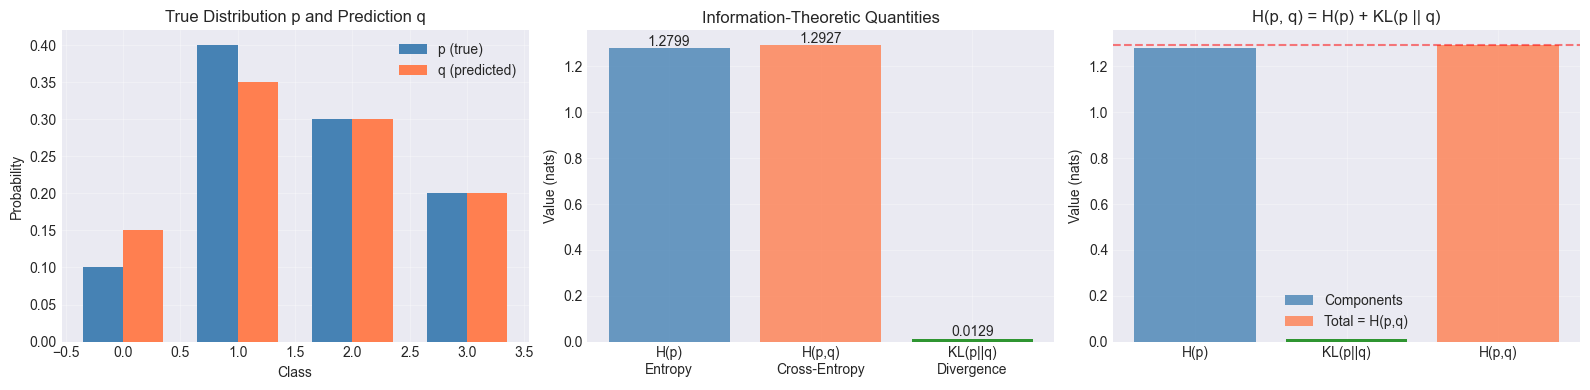

- High Entropy means the data itself is messy/uncertain. (Not ideal, but out of your model's control).
- Low KL Divergence means your model perfectly understands that messiness. (This is very good!).

Here is a breakdown of why a small KL divergence is actually excellent news, even when entropy is high:
1. Entropy is the 'Difficulty of the Exam'
Entropy H(p) belongs entirely to the real world (p). It measures how inherently unpredictable the truth is.
	- A distribution like [0.1, 0.4, 0.3, 0.2] is like a very hard, confusing multiple-choice exam where almost every answer looks plausible.
	- You cannot change the exam questions. The high uncertainty (1.279854) just means the problem you are trying to solve is highly complex or noisy.

2. KL Divergence is 'How Well the Student Prepared'
KL Divergence measures the distance between the truth (p) and your model's belief (q). It asks: 'Given how messy the real world is, did the model accurately figure out that messiness?'
	- Your model predi

In [52]:
# ---------- INFORMATION THEORY SUMMARY ----------
print("\n--- INFORMATION THEORY SUMMARY ---")

# Relationship: H(p, q) = H(p) + KL(p || q)
p = torch.tensor([0.1, 0.4, 0.3, 0.2])
q = torch.tensor([0.15, 0.35, 0.30, 0.20])

H_p = entropy_torch(p)
H_pq = cross_entropy_torch(p, q)
KL_pq = kl_divergence_torch(p, q)

print(f"p = {p.numpy()}")
print(f"q = {q.numpy()}")
print()
print(f"H(p)         = {H_p.item():.6f}  (entropy of p)")
print(f"H(p, q)      = {H_pq.item():.6f}  (cross-entropy)")
print(f"KL(p || q)   = {KL_pq.item():.6f}  (KL divergence)")
print(f"H(p) + KL(p||q) = {(H_p + KL_pq).item():.6f}")
print()
print(f"Verify: H(p, q) = H(p) + KL(p || q)  →  {H_pq.item():.6f} ≈ {(H_p + KL_pq).item():.6f}")
print()
print("Key identities:")
print("  1. Cross-entropy = Entropy + KL divergence")
print("  2. Minimizing cross-entropy = minimizing KL divergence (when p is fixed)")
print("  3. This is exactly what happens during training: p is the true label distribution,")
print("     q is the model's prediction, and we minimize H(p, q).\n")

# Visualize the relationship
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution p and q
x_pos = np.arange(4)
width = 0.35
axes[0].bar(x_pos - width/2, p.numpy(), width, label='p (true)', color='steelblue')
axes[0].bar(x_pos + width/2, q.numpy(), width, label='q (predicted)', color='coral')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Probability')
axes[0].set_title('True Distribution p and Prediction q')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Entropy, Cross-entropy, KL as bars
metrics = ['H(p)\nEntropy', 'H(p,q)\nCross-Entropy', 'KL(p||q)\nDivergence']
values = [H_p.item(), H_pq.item(), KL_pq.item()]
colors = ['steelblue', 'coral', 'green']
axes[1].bar(metrics, values, color=colors, alpha=0.8)
for i, v in enumerate(values):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)
axes[1].set_ylabel('Value (nats)')
axes[1].set_title('Information-Theoretic Quantities')
axes[1].grid(True, alpha=0.3)

# Decomposition visualization
axes[2].bar(['H(p)', 'KL(p||q)'], [H_p.item(), KL_pq.item()], 
            color=['steelblue', 'green'], alpha=0.8, label='Components')
axes[2].bar(['H(p,q)'], [H_pq.item()], color='coral', alpha=0.8, 
            label='Total = H(p,q)')
axes[2].axhline(y=H_pq.item(), color='red', linestyle='--', alpha=0.5)
axes[2].set_ylabel('Value (nats)')
axes[2].set_title('H(p, q) = H(p) + KL(p || q)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("- High Entropy means the data itself is messy/uncertain. (Not ideal, but out of your model's control).")
print("- Low KL Divergence means your model perfectly understands that messiness. (This is very good!).")
print("\nHere is a breakdown of why a small KL divergence is actually excellent news, even when entropy is high:")
print("1. Entropy is the 'Difficulty of the Exam'\nEntropy H(p) belongs entirely to the real world (p). It measures how inherently unpredictable the truth is.\n\t- A distribution like [0.1, 0.4, 0.3, 0.2] is like a very hard, confusing multiple-choice exam where almost every answer looks plausible.\n\t- You cannot change the exam questions. The high uncertainty (1.279854) just means the problem you are trying to solve is highly complex or noisy.\n")
print("2. KL Divergence is 'How Well the Student Prepared'\nKL Divergence measures the distance between the truth (p) and your model's belief (q). It asks: 'Given how messy the real world is, did the model accurately figure out that messiness?'\n\t- Your model predicted q = [0.15, 0.35, 0.30, 0.20].")
print("\t- The model didn't falsely claim, ""I'm 100% sure it's Class 2!"" Instead, the model correctly realized, ""Hey, this is a highly uncertain situation, and the probabilities are split\n\t  almost exactly like 10%, 40%, 30%, 20%.""")
print("Because the model's guess (q) is an almost perfect match for the real-world messiness (p), the KL Divergence is tiny (0.012866).")
print("\nIn machine learning, our goal is to get our loss as close to zero as possible, so seeing a Cross-Entropy (CE) of 1.292720 feels like the model is performing poorly.")
print("Cross-Entropy is high only because the baseline Entropy H(p) is high, not because the model did a bad job.")
print("\nSummary\nHigh entropy means the problem is tough. A small KL divergence means your model handled the tough problem beautifully by mirroring that exact uncertainty. Your model is not being penalized\nbecause the data is uncertain; it is being rewarded because its own uncertainty perfectly matches the data's uncertainty.")